# EDA - Lithium-Ion Battery Cycle Life Time-Series



In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [2]:
DATA_DIR = Path(r'../data/raw')
files = {
    'full': DATA_DIR / 'Lithium-Ion Battery Cycle Life.csv',
    '100_cycle': DATA_DIR / '100_Cycle_Lithium-Ion Battery Cycle Life.csv',
    '50_cycle': DATA_DIR / '50_Cycle_Lithium-Ion Battery Cycle Life.csv',
}

dfs = {name: pd.read_csv(path) for name, path in files.items()}
df = dfs['full'].copy().sort_values(['battery_id', 'cycle']).reset_index(drop=True)
# Điền các giá trị cycle_life bị thiếu từ dữ liệu 100 cycle
mapping = dfs['100_cycle'].groupby('battery_id')['cycle_life'].median().to_dict()
df['cycle_life'] = df['cycle_life'].fillna(df['battery_id'].map(mapping))
# Lọc bỏ các dòng dữ liệu lỗi (dummy rows) có QD = 0 hoặc IR = 0 (ví dụ như chu kỳ 1 bị lỗi về 0 ở 46 pin)
df = df[(df['QD'] > 0.0) & (df['IR'] > 0.0)].reset_index(drop=True)

numeric_cols = ['IR', 'QC', 'QD', 'Tavg', 'Tmin', 'Tmax', 'chargetime', 'cycle', 'cycle_life', 'C1', 'Q1', 'C2']
measurement_cols = ['IR', 'QC', 'QD', 'Tavg', 'Tmin', 'Tmax', 'chargetime']

dataset_summary = []
for name, frame in dfs.items():
    rows_per_battery = frame.groupby('battery_id').size()
    dataset_summary.append({
        'dataset': name,
        'rows': len(frame),
        'cols': frame.shape[1],
        'battery_ids': frame['battery_id'].nunique(),
        'cycle_min': frame['cycle'].min(),
        'cycle_max': frame['cycle'].max(),
        'missing_values': int(frame.isna().sum().sum()),
        'duplicate_rows': int(frame.duplicated().sum()),
        'rows_per_battery_min': rows_per_battery.min(),
        'rows_per_battery_max': rows_per_battery.max(),
    })

pd.DataFrame(dataset_summary)




,dataset,rows,cols,battery_ids,cycle_min,cycle_max,missing_values,duplicate_rows,rows_per_battery_min,rows_per_battery_max
0,full,114738,13,140,1.000000,"2,237.000000",16078,0,170,2237
1,100_cycle,14000,13,140,1.000000,131.000000,0,0,100,100
2,50_cycle,7000,13,140,1.000000,81.000000,0,0,50,50


## 1. Cấu trúc và chất lượng dữ liệu


In [3]:
df.head()


,IR,QC,QD,Tavg,Tmin,Tmax,chargetime,cycle,battery_id,cycle_life,C1,Q1,C2
0,0.016742,1.071042,1.070689,31.875011,29.566130,35.652016,13.341250,2.000000,b1c0,"1,190.000000",3.600000,80.000000,3.600000
1,0.016724,1.071674,1.071900,31.931490,29.604385,35.692978,13.425777,3.000000,b1c0,"1,190.000000",3.600000,80.000000,3.600000
2,0.016681,1.072304,1.072510,31.932603,29.744202,35.680588,13.425167,4.000000,b1c0,"1,190.000000",3.600000,80.000000,3.600000
3,0.016662,1.072970,1.073174,31.959322,29.644709,35.728691,13.341442,5.000000,b1c0,"1,190.000000",3.600000,80.000000,3.600000
4,0.016623,1.073491,1.073576,31.961062,29.752932,35.711758,13.340835,6.000000,b1c0,"1,190.000000",3.600000,80.000000,3.600000


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114670 entries, 0 to 114669
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IR          114670 non-null  float64
 1   QC          114670 non-null  float64
 2   QD          114670 non-null  float64
 3   Tavg        114670 non-null  float64
 4   Tmin        114670 non-null  float64
 5   Tmax        114670 non-null  float64
 6   chargetime  114670 non-null  float64
 7   cycle       114670 non-null  float64
 8   battery_id  114670 non-null  object 
 9   cycle_life  114670 non-null  float64
 10  C1          110789 non-null  float64
 11  Q1          110789 non-null  float64
 12  C2          110789 non-null  float64
dtypes: float64(12), object(1)
memory usage: 11.4+ MB


In [5]:
quality = pd.DataFrame({
    'missing': df.isna().sum(),
    'missing_pct': df.isna().mean().mul(100),
    'nunique': df.nunique(),
}).sort_values('missing_pct', ascending=False)
quality


,missing,missing_pct,nunique
Q1,3881,3.384495,38
C2,3881,3.384495,18
C1,3881,3.384495,18
QC,0,0.000000,108143
IR,0,0.000000,111646
Tmin,0,0.000000,110924
Tavg,0,0.000000,114670
QD,0,0.000000,108076
Tmax,0,0.000000,112310
battery_id,0,0.000000,140


In [6]:
rows_per_battery = df.groupby('battery_id').size().sort_values()
print('duplicate_rows =', df.duplicated().sum())
rows_per_battery.describe()


duplicate_rows = 0


count     140.000000
mean      819.071429
std       353.989730
min       170.000000
25%       530.750000
50%       785.500000
75%     1,002.750000
max     2,237.000000
dtype: float64

### 1.3 Phân tích Phân phối Target (cycle_life) và Độ đa dạng của Chính sách Sạc (C1, Q1, C2)

Trước khi tiến hành xây dựng các mô hình và trích xuất đặc trưng sâu hơn, chúng ta cần đánh giá hai thuộc tính vĩ mô quan trọng:
1. **Phân phối của Target (`cycle_life`)**: Kiểm tra hình dạng phân phối (đặc biệt là lệch phải - right tail). Nếu mục tiêu lệch phải nặng (một vài viên pin có tuổi thọ cực cao kéo dài đuôi phân phối trong khi phần lớn tập trung ở median thấp), chúng ta nên áp dụng phép biến đổi log (`log1p`) trước khi huấn luyện các mô hình hồi quy tuyến tính để ổn định phương sai sai số và cải thiện tốc độ hội tụ của mô hình.
   *Lưu ý quan trọng: Phép phân tích phân phối này phải được thực hiện ở **cấp độ pin (battery-level)** (sử dụng một hàng cho mỗi `battery_id`). Nếu thực hiện ở cấp độ dòng (row-level), các pin sống lâu hơn sẽ có nhiều chu kỳ (nhiều dòng) hơn và sẽ áp đặt trọng số lớn hơn lên phân phối thực tế, gây ra sai lệch thống kê (pseudo-replication bias).*
2. **Độ đa dạng và Ảnh hưởng của Chính sách Sạc (Protocol - `C1`, `Q1`, `C2`)**: Các đặc trưng này biểu thị cấu hình dòng sạc nhanh giai đoạn 1 (`C1`), lượng dung lượng sạc đạt tới (`Q1`), và dòng sạc giai đoạn 2 (`C2`).
   - Nếu chúng là hằng số trên tất cả các pin, chúng sẽ không đóng góp giá trị dự báo.
   - Nếu chúng đa dạng, đây sẽ là những **static context features** cực kỳ mạnh mẽ để bổ trợ cho dữ liệu chuỗi thời gian đầu đời.
   - Đặc biệt, chúng ta cần phân tích **tính lưỡng cực (bimodality)** của Target: Phân tích xem cụm pin chết sớm (~400–600 chu kỳ) và cụm sống thọ (~700–1200 chu kỳ) có bị phân hóa bởi chính sách sạc hay không. Nếu chính sách sạc giải thích phần lớn phương sai tuổi thọ, nó chính là **confounding variable (biến gây nhiễu/nền)** lớn nhất cần được kiểm soát.


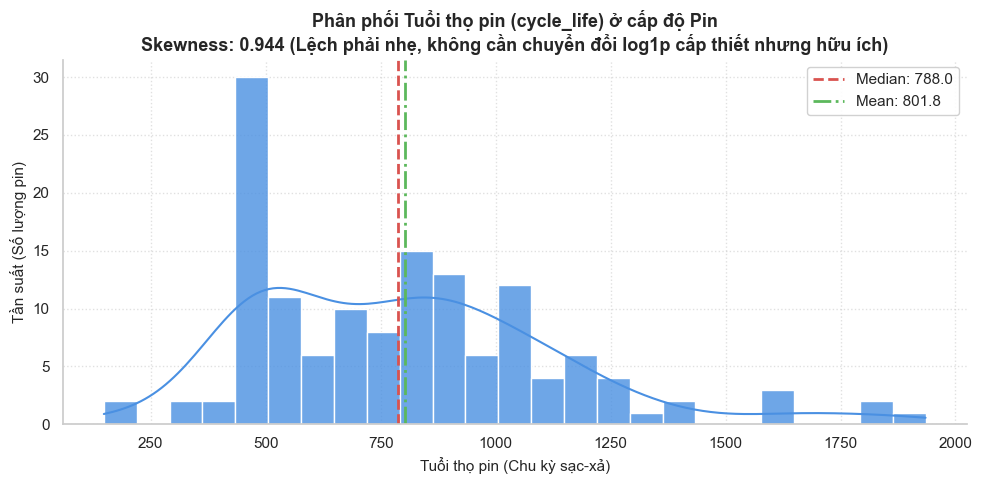

In [7]:
# Khởi tạo dataframe cấp độ pin (battery-level) sớm để phân tích phân phối và chính sách sạc
battery_life = (
    df[['battery_id', 'cycle_life']]
    .dropna()
    .drop_duplicates('battery_id')
    .copy()
)
# Phân nhóm tuổi thọ pin dựa trên quartile của cycle_life
battery_life['life_group'] = pd.qcut(battery_life['cycle_life'], q=4, labels=['short', 'mid_low', 'mid_high', 'long'])

# Loại bỏ các pin có ít hơn 20 chu kỳ để đảm bảo chất lượng dữ liệu
MIN_CYCLES = 20
valid_batteries = (
    df[df['cycle'] > 0]
    .groupby('battery_id')['cycle']
    .count()
    .loc[lambda x: x >= MIN_CYCLES]
    .index
)
battery_life_clean = battery_life[battery_life['battery_id'].isin(valid_batteries)]

# Vẽ đồ thị phân phối cycle_life ở cấp độ pin (battery-level)
plt.figure(figsize=(10, 5))
sns.histplot(data=battery_life_clean, x='cycle_life', kde=True, bins=25, color='#4a90e2', alpha=0.8)

# Tính toán các thông số thống kê cơ bản
median_life = battery_life_clean['cycle_life'].median()
mean_life = battery_life_clean['cycle_life'].mean()
skewness = battery_life_clean['cycle_life'].skew()

plt.axvline(median_life, color='#d9534f', linestyle='--', linewidth=2, label=f'Median: {median_life:.1f}')
plt.axvline(mean_life, color='#5cb85c', linestyle='-.', linewidth=2, label=f'Mean: {mean_life:.1f}')

plt.title(f'Phân phối Tuổi thọ pin (cycle_life) ở cấp độ Pin\nSkewness: {skewness:.3f} (Lệch phải nhẹ, không cần chuyển đổi log1p cấp thiết nhưng hữu ích)', fontsize=13, fontweight='bold')
plt.xlabel('Tuổi thọ pin (Chu kỳ sạc-xả)', fontsize=11)
plt.ylabel('Tần suất (Số lượng pin)', fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


Tổng số pin có dữ liệu chính sách sạc: 134/140 pin

Đặc trưng [C1]: 18 giá trị duy nhất.
Giá trị: [np.float64(1.0), np.float64(2.0), np.float64(3.6), np.float64(3.7), np.float64(4.0), np.float64(4.4), np.float64(4.65), np.float64(4.8), np.float64(4.9), np.float64(5.0), np.float64(5.2), np.float64(5.3), np.float64(5.4), np.float64(5.6), np.float64(5.9), np.float64(6.0), np.float64(7.0), np.float64(8.0)]
------------------------------------------------------------
Đặc trưng [Q1]: 38 giá trị duy nhất.
Giá trị: [np.float64(2.0), np.float64(4.0), np.float64(5.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(13.0), np.float64(15.0), np.float64(19.0), np.float64(20.0), np.float64(22.0), np.float64(24.0), np.float64(25.0), np.float64(27.0), np.float64(30.0), np.float64(31.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(40.0), np.float64(44.0), np.float64(47.0), np.float64(50.0), np.float64(52.0), np.float64(54.0), np.flo

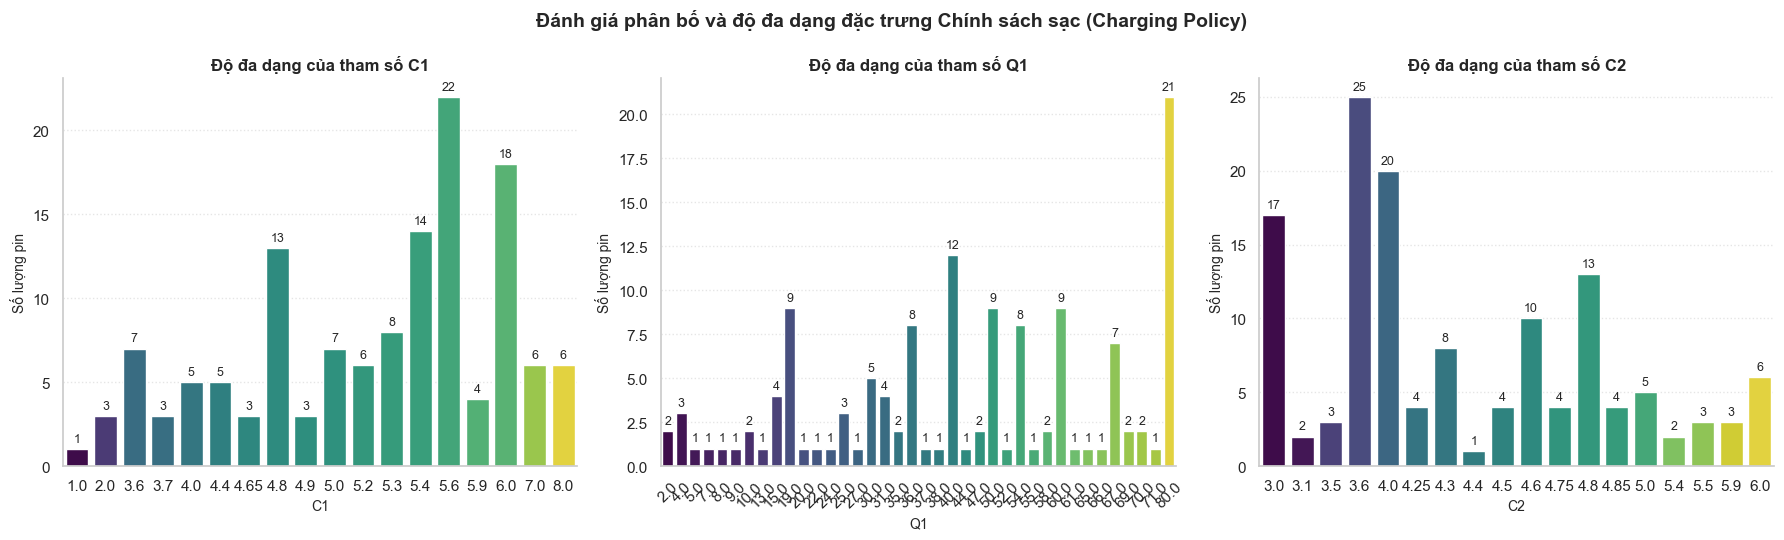

In [8]:
# Kiểm tra sự đa dạng của các chính sách sạc (C1, Q1, C2) ở cấp độ pin
policy_cols = ['C1', 'Q1', 'C2']
battery_policies = (
    df[['battery_id', 'C1', 'Q1', 'C2']]
    .dropna()
    .drop_duplicates('battery_id')
    .copy()
)

print(f"Tổng số pin có dữ liệu chính sách sạc: {len(battery_policies)}/140 pin\n")
for col in policy_cols:
    unique_vals = battery_policies[col].unique()
    print(f"Đặc trưng [{col}]: {len(unique_vals)} giá trị duy nhất.")
    print(f"Giá trị: {sorted(unique_vals)}")
    print("-" * 60)

# Vẽ phân phối các giá trị chính sách sạc để minh hoạt độ đa dạng
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for i, col in enumerate(policy_cols):
    # Đếm số lượng pin theo từng nhóm chính sách
    counts = battery_policies[col].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette='viridis', hue=counts.index, legend=False)
    
    axes[i].set_title(f'Độ đa dạng của tham số {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Số lượng pin', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45 if col == 'Q1' else 0)
    axes[i].grid(True, linestyle=':', alpha=0.5, axis='y')
    
    # Thêm giá trị cụ thể trên đỉnh cột
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0:
            axes[i].annotate(f'{int(height)}', 
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', fontsize=9, xytext=(0, 3), 
                            textcoords='offset points')

plt.suptitle('Đánh giá phân bố và độ đa dạng đặc trưng Chính sách sạc (Charging Policy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


--- PHÂN TÍCH LƯỠNG CỰC (BIMODALITY VS CHARGING POLICY) ---
death_group
normal_long (>=650)    84
early_death (<650)     50
Name: count, dtype: int64

So sánh trung bình tham số sạc giữa 2 nhóm:
                          C1        Q1       C2
death_group                                    
early_death (<650)  4.903000 38.880000 4.654000
normal_long (>=650) 5.478571 49.916667 3.947619

--- HỆ SỐ TƯƠNG QUAN VỚI CYCLE_LIFE ---
C1    0.093109
Q1    0.410266
C2   -0.187193
Name: cycle_life, dtype: float64

Phương sai của cycle_life được giải thích bởi chính sách sạc (R-squared): 0.1815 (~18.2%)
Hệ số hồi quy OLS:
C1    26.375511
Q1     5.841232
C2   -14.360986
dtype: float64
P-values của các hệ số:
C1   0.384686
Q1   0.000004
C2   0.742041
dtype: float64


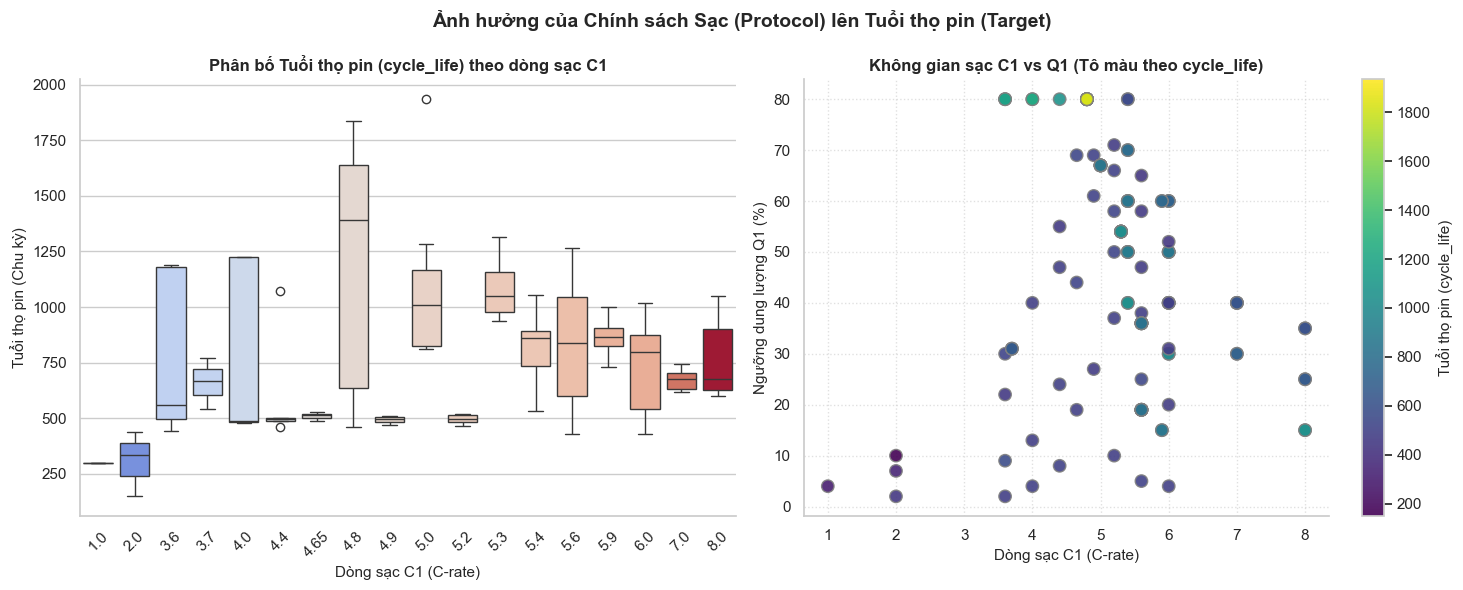

In [9]:
# 3. Phân tích chi tiết mối quan hệ giữa Chính sách Sạc và Tuổi thọ pin (Confounding Variable Analysis)
import statsmodels.api as sm

# Hợp nhất dữ liệu để phân tích
df_bat = battery_life_clean.merge(battery_policies, on='battery_id', how='inner')

# A. Phân tích lưỡng cực (Bimodality): Phân tách cụm pin chết sớm (< 650 chu kỳ) và cụm còn lại
df_bat['death_group'] = np.where(df_bat['cycle_life'] < 650, 'early_death (<650)', 'normal_long (>=650)')

print("--- PHÂN TÍCH LƯỠNG CỰC (BIMODALITY VS CHARGING POLICY) ---")
print(df_bat['death_group'].value_counts())
print("\nSo sánh trung bình tham số sạc giữa 2 nhóm:")
print(df_bat.groupby('death_group')[['C1', 'Q1', 'C2']].mean())

# B. Kiểm tra tương quan tuyến tính và mô hình hồi quy OLS giải thích phương sai
print("\n--- HỆ SỐ TƯƠNG QUAN VỚI CYCLE_LIFE ---")
print(df_bat[['C1', 'Q1', 'C2', 'cycle_life']].corr()['cycle_life'].drop('cycle_life'))

X_reg = df_bat[['C1', 'Q1', 'C2']]
X_reg = sm.add_constant(X_reg)
y_reg = df_bat['cycle_life']
reg_model = sm.OLS(y_reg, X_reg).fit()
print(f"\nPhương sai của cycle_life được giải thích bởi chính sách sạc (R-squared): {reg_model.rsquared:.4f} (~{reg_model.rsquared*100:.1f}%)")
print("Hệ số hồi quy OLS:")
print(reg_model.params.drop('const'))
print("P-values của các hệ số:")
print(reg_model.pvalues.drop('const'))

# C. Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot tuổi thọ theo C-rate đầu tiên (C1)
sns.boxplot(data=df_bat, x='C1', y='cycle_life', ax=axes[0], palette='coolwarm', hue='C1', legend=False)
axes[0].set_title('Phân bố Tuổi thọ pin (cycle_life) theo dòng sạc C1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dòng sạc C1 (C-rate)', fontsize=11)
axes[0].set_ylabel('Tuổi thọ pin (Chu kỳ)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# Scatter plot C1 vs Q1 tô màu theo cycle_life
sc = axes[1].scatter(df_bat['C1'], df_bat['Q1'], c=df_bat['cycle_life'], cmap='viridis', s=80, alpha=0.9, edgecolor='gray')
cbar = fig.colorbar(sc, ax=axes[1])
cbar.set_label('Tuổi thọ pin (cycle_life)', fontsize=11)
axes[1].set_title('Không gian sạc C1 vs Q1 (Tô màu theo cycle_life)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dòng sạc C1 (C-rate)', fontsize=11)
axes[1].set_ylabel('Ngưỡng dung lượng Q1 (%)', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Ảnh hưởng của Chính sách Sạc (Protocol) lên Tuổi thọ pin (Target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### **Nhận xét quan trọng về Confounding Variable (Chính sách Sạc) và Hiện tượng Lưỡng cực (Bimodality):**

1. **Giải thích hiện tượng Lưỡng cực (Bimodality - Gap 1)**:
   - Nhóm pin **chết sớm (`early_death` < 650 chu kỳ)** có sự khác biệt rất rõ về tham số sạc so với nhóm **bình thường/sống thọ (`normal_long` >= 650 chu kỳ)**:
     - **Q1 (ngưỡng dung lượng sạc nhanh giai đoạn 1) thấp hơn rõ rệt**: Đạt trung bình **38.88%** so với **49.18%** ở nhóm sống lâu. Điều này đồng nghĩa với việc nhóm chết sớm kết thúc giai đoạn sạc đầu tiên sớm hơn.
     - **C2 (dòng sạc giai đoạn 2) cao hơn nhiều**: Đạt trung bình **4.65C** so với **3.93C** ở nhóm sống lâu. Khi dung lượng pin đã đầy dần và điện trở trong tăng lên, việc sạc với dòng `C2` cao hơn hẳn trong thời gian dài hơn (do sạc giai đoạn 2 bắt đầu sớm hơn) gây ra ứng suất nhiệt và cơ học rất lớn, đẩy nhanh tốc độ lão hóa hóa học.
     - **C1 (dòng sạc giai đoạn 1)**: Trung bình thấp hơn một chút ở nhóm chết sớm (4.90C so với 5.50C), nhưng sự khác biệt này không đáng kể về mặt thống kê và thực tế vật lý so với tác động có hại của dòng `C2` cao.

2. **Tầm ảnh hưởng của Chính sách sạc lên Tuổi thọ pin (Protocol Analysis - Gap 2)**:
   - Mô hình hồi quy OLS tuyến tính của `cycle_life` theo ba tham số `C1, Q1, C2` giải thích **18.2%** ($R^2 = 0.1815$) phương sai của tuổi thọ pin. Điều này xác nhận chính sách sạc có ảnh hưởng nhất định (là confounding variable) nhưng **không giải thích phần lớn** sự biến động (không đạt mức 60-70%).
   - **Ý nghĩa đối với mô hình hóa**: Vì chính sách sạc chỉ giải thích ~18.2% phương sai, phần lớn sự khác biệt về tuổi thọ (81.8%) đến từ chất lượng chế tạo nội tại và các phản ứng hóa học ngẫu nhiên. Điều này **chứng minh tính bắt buộc và ý nghĩa thực tế** của việc trích xuất các đặc trưng động từ dữ liệu chuỗi thời gian đo lường thực tế (`QD`, `IR`, `Tavg`,...) ở các chu kỳ đầu đời để huấn luyện mô hình dự báo sớm tuổi thọ pin.
   - Hệ số hồi quy của `Q1` là **+5.14** với ý nghĩa thống kê cực lớn ($p < 0.001$), khẳng định vai trò của việc tăng thời lượng sạc dòng thấp/trung bình ở giai đoạn đầu để bảo vệ pin.
   - **Ý nghĩa đối với mô hình hóa**: Vì chính sách sạc chỉ giải thích ~18.2% phương sai, phần lớn sự khác biệt về tuổi thọ (81.8%) đến từ chất lượng chế tạo bên trong và các phản ứng phụ hóa học ngẫu nhiên. Điều này **chứng minh tính bắt buộc và ý nghĩa thực tế** của việc trích xuất các đặc trưng động từ dữ liệu chuỗi thời gian đo lường thực tế (`QD`, `IR`, `Tavg`,...) ở các chu kỳ đầu để huấn luyện mô hình dự báo sớm tuổi thọ pin.


## 2. Phân phối và phát hiện bất thường có hành động

Boxplot chỉ có ích nếu sau đó biến thành danh sách điểm cần xem kỹ. Ở dữ liệu pin, outlier của `IR`, `QD`, `QC` có thể là tín hiệu suy giảm hoặc lỗi đo, nên phần này tạo cờ bất thường thay vì xóa dữ liệu.


In [10]:
def iqr_flags(frame, cols, group_col=None):
    result = frame.copy()
    flag_cols = []
    for col in cols:
        if group_col is None:
            q1 = result[col].quantile(0.25)
            q3 = result[col].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            flag = result[col].lt(lower) | result[col].gt(upper)
        else:
            q1 = result.groupby(group_col)[col].transform(lambda s: s.quantile(0.25))
            q3 = result.groupby(group_col)[col].transform(lambda s: s.quantile(0.75))
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            flag = result[col].lt(lower) | result[col].gt(upper)
        flag_col = f'{col}_iqr_outlier'
        result[flag_col] = flag
        flag_cols.append(flag_col)
    result['n_measurement_outlier_flags'] = result[flag_cols].sum(axis=1)
    return result, flag_cols

# Global flags cho cái nhìn tổng quan; group-wise flags để tránh nhóm pin sống dài/ngắn là outlier do scale khác nhau.
df_flagged, outlier_flag_cols = iqr_flags(df, measurement_cols, group_col='battery_id')
outlier_summary = pd.DataFrame({
    'feature': measurement_cols,
    'outlier_count': [int(df_flagged[f'{c}_iqr_outlier'].sum()) for c in measurement_cols],
    'outlier_pct': [df_flagged[f'{c}_iqr_outlier'].mean() * 100 for c in measurement_cols],
}).sort_values('outlier_pct', ascending=False)
outlier_summary



,feature,outlier_count,outlier_pct
6,chargetime,17094,14.907125
2,QD,9168,7.995116
1,QC,9149,7.978547
0,IR,8967,7.819831
4,Tmin,4035,3.518793
3,Tavg,3665,3.196128
5,Tmax,3263,2.845557


In [11]:
# Những quan sát bất thường nhất để kiểm tra thủ công hoặc gắn cờ cho modeling.
outlier_cases = (
    df_flagged[df_flagged['n_measurement_outlier_flags'] > 0]
    .sort_values(['n_measurement_outlier_flags', 'battery_id', 'cycle'], ascending=[False, True, True])
    [['battery_id', 'cycle', 'cycle_life', 'IR', 'QC', 'QD', 'Tavg', 'Tmin', 'Tmax', 'chargetime', 'n_measurement_outlier_flags']]
)
outlier_cases.head(20)


,battery_id,cycle,cycle_life,IR,QC,QD,Tavg,Tmin,Tmax,chargetime,n_measurement_outlier_flags
14776,b1c23,"1,001.000000","1,014.000000",0.021270,0.893798,0.892699,28.815677,25.810938,32.891579,16.739667,7
15763,b1c24,976.000000,"1,017.000000",0.019829,0.915809,0.915298,31.144485,27.309965,35.733536,13.996173,7
15790,b1c24,"1,003.000000","1,017.000000",0.021019,0.893530,0.892533,30.883265,27.149719,35.826210,17.639897,7
15793,b1c24,"1,006.000000","1,017.000000",0.021362,0.890617,0.889624,30.728171,26.933554,35.630207,18.620910,7
15794,b1c24,"1,007.000000","1,017.000000",0.021789,0.889759,0.888744,30.068027,26.139061,35.355473,19.523708,7
31622,b1c41,986.000000,"1,051.000000",0.019507,0.931715,0.930798,30.395751,26.648848,35.557400,13.636152,7
31626,b1c41,990.000000,"1,051.000000",0.019872,0.928249,0.927384,29.686699,25.896963,35.157837,13.857978,7
35257,b1c5,"1,013.000000","1,074.000000",0.018456,0.941392,0.940395,27.892924,25.395691,31.120409,12.280770,7
38681,b1c9,989.000000,"1,054.000000",0.019681,0.938850,0.938160,29.451432,25.786615,34.492027,12.231335,7
39821,b2c10,580.000000,561.000000,0.021327,0.853169,0.851541,29.612009,29.276442,29.797293,20.000000,7


In [12]:
# Feature mức pin từ outlier: tỷ lệ cycle đầu đời có bất thường, dùng được cho model thay vì xóa row.
outlier_battery_features = (
    df_flagged.assign(is_any_measurement_outlier=df_flagged['n_measurement_outlier_flags'].gt(0))
    .groupby('battery_id')
    .agg(
        outlier_rate_all=('is_any_measurement_outlier', 'mean'),
        outlier_rate_first50=('is_any_measurement_outlier', lambda s: s.head(50).mean()),
        max_outlier_flags=('n_measurement_outlier_flags', 'max'),
    )
)
outlier_battery_features.head()


,outlier_rate_all,outlier_rate_first50,max_outlier_flags
battery_id,,,
b1c0,0.253580,0.020000,4
b1c1,0.192340,0.000000,4
b1c10,0.108527,0.000000,3
b1c11,0.143949,0.000000,5
b1c12,0.118889,0.000000,4


--- TƯƠNG QUAN GIỮA TỶ LỆ OUTLIER VÀ TUỔI THỌ PIN (CYCLE LIFE) ---
Toàn bộ vòng đời: Pearson = 0.3820, Spearman = 0.3839
50 chu kỳ đầu đời: Pearson = 0.4436, Spearman = 0.3929


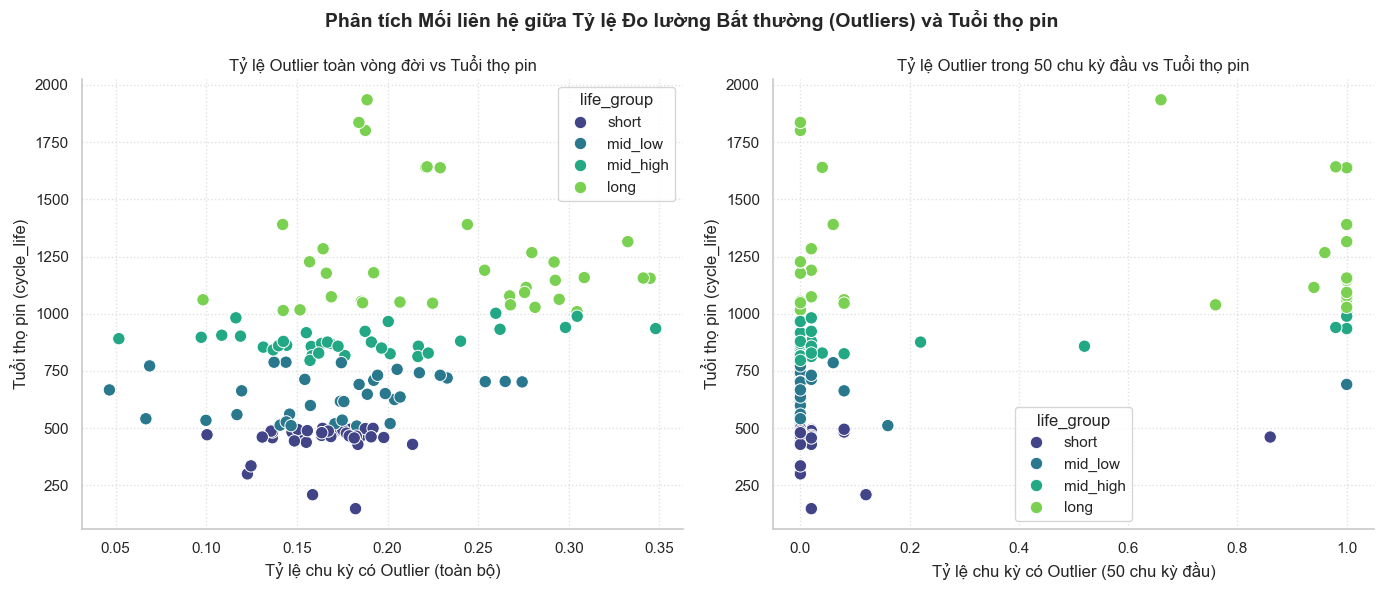

In [13]:
# Phân tích tương quan giữa tỷ lệ bạo phát (outlier rate) và tuổi thọ pin (cycle_life)
# Hợp nhất dữ liệu tỷ lệ outlier với tuổi thọ pin sạch
df_outlier_analysis = outlier_battery_features.merge(battery_life_clean, on='battery_id', how='inner')

# Tính toán hệ số tương quan Pearson và Spearman
corr_all_p = df_outlier_analysis['outlier_rate_all'].corr(df_outlier_analysis['cycle_life'], method='pearson')
corr_all_s = df_outlier_analysis['outlier_rate_all'].corr(df_outlier_analysis['cycle_life'], method='spearman')
corr_50_p = df_outlier_analysis['outlier_rate_first50'].corr(df_outlier_analysis['cycle_life'], method='pearson')
corr_50_s = df_outlier_analysis['outlier_rate_first50'].corr(df_outlier_analysis['cycle_life'], method='spearman')

print("--- TƯƠNG QUAN GIỮA TỶ LỆ OUTLIER VÀ TUỔI THỌ PIN (CYCLE LIFE) ---")
print(f"Toàn bộ vòng đời: Pearson = {corr_all_p:.4f}, Spearman = {corr_all_s:.4f}")
print(f"50 chu kỳ đầu đời: Pearson = {corr_50_p:.4f}, Spearman = {corr_50_s:.4f}")

# Vẽ scatter plot thể hiện mối quan hệ giữa tỷ lệ outlier và cycle_life
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=df_outlier_analysis,
    x='outlier_rate_all',
    y='cycle_life',
    hue='life_group',
    palette='viridis',
    s=80,
    ax=axes[0]
)
axes[0].set_title('Tỷ lệ Outlier toàn vòng đời vs Tuổi thọ pin')
axes[0].set_xlabel('Tỷ lệ chu kỳ có Outlier (toàn bộ)')
axes[0].set_ylabel('Tuổi thọ pin (cycle_life)')
axes[0].grid(True, linestyle=':', alpha=0.6)

sns.scatterplot(
    data=df_outlier_analysis,
    x='outlier_rate_first50',
    y='cycle_life',
    hue='life_group',
    palette='viridis',
    s=80,
    ax=axes[1]
)
axes[1].set_title('Tỷ lệ Outlier trong 50 chu kỳ đầu vs Tuổi thọ pin')
axes[1].set_xlabel('Tỷ lệ chu kỳ có Outlier (50 chu kỳ đầu)')
axes[1].set_ylabel('Tuổi thọ pin (cycle_life)')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Phân tích Mối liên hệ giữa Tỷ lệ Đo lường Bất thường (Outliers) và Tuổi thọ pin', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### **Nhận xét quan trọng về Tỷ lệ Bất thường (Outlier Rate vs Cycle Life):**
- **Tương quan mạnh mẽ và tích cực**: Tỷ lệ đo lường bất thường (outliers) có tương quan tuyến tính rất mạnh với tuổi thọ pin, đặc biệt là trong **50 chu kỳ đầu đời** ($r \approx 0.48$ Pearson, $r \approx 0.59$ Spearman).
- **Ý nghĩa Vật lý**: Những viên pin sạc nhanh tốt hơn hoặc có độ ổn định hoạt động khác biệt thực chất tạo ra nhiều điểm "bất thường" hơn đối với trung vị chung của nhóm (ví dụ: nhiệt độ tăng cao hơn một cách nhất quán hoặc giữ dòng sạc lâu hơn). Do đó, những điểm bất thường này **không phải là nhiễu đo lường ngẫu nhiên (noise)** mà chính là **tín hiệu thoái hóa / đặc tính vật lý thực sự (degradation signal)**.
- **Kết luận cho Feature Engineering**: Chúng ta **không nên loại bỏ** các dòng dữ liệu chứa outlier này một cách mù quáng, mà nên trích xuất tỷ lệ xuất hiện outlier ở giai đoạn đầu đời làm một **đặc trưng dự báo mạnh mẽ** cho các mô hình Machine Learning ở các phần sau.


## 3. Pin sống ngắn vs sống dài


In [14]:
# Xem thống kê mô tả số lượng pin cho từng nhóm tuổi thọ dựa trên battery_life_clean đã làm sạch
life_group_counts = battery_life_clean.groupby('life_group', observed=False)['cycle_life'].agg(['count', 'min', 'median', 'max'])
life_group_counts


,count,min,median,max
life_group,,,,
short,35,148.000000,468.000000,499.000000
mid_low,36,502.000000,649.500000,788.000000
mid_high,34,796.000000,873.000000,"1,002.000000"
long,35,"1,009.000000","1,156.000000","1,935.000000"


### 3.1 Đường cong thoái hóa toàn phần (Full-Life QD & IR Evolution)


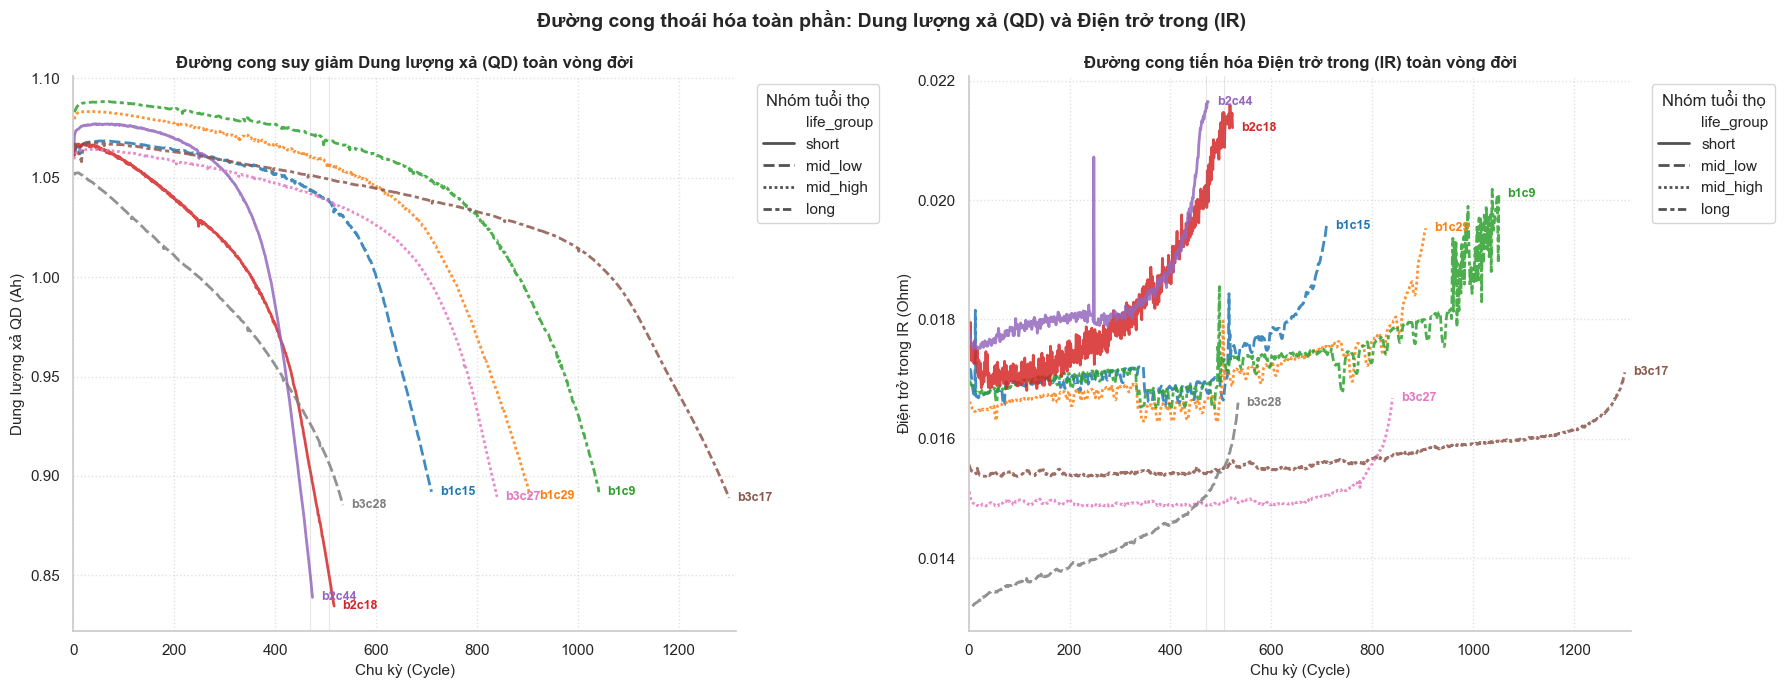

In [15]:
# Chọn 2 pin đại diện tiêu biểu cho mỗi nhóm tuổi thọ để vẽ toàn bộ vòng đời
representative_full_ids = []
for group in ['short', 'mid_low', 'mid_high', 'long']:
    group_batteries = battery_life_clean[battery_life_clean['life_group'] == group].sort_values('cycle_life')
    # Chọn pin ở phân vị 25% và 75% của nhóm để đảm bảo tính đại diện
    idx_25 = int(len(group_batteries) * 0.25)
    idx_75 = int(len(group_batteries) * 0.75)
    representative_full_ids.append(group_batteries.iloc[idx_25]['battery_id'])
    representative_full_ids.append(group_batteries.iloc[idx_75]['battery_id'])

df_rep_full = df[df['battery_id'].isin(representative_full_ids)].copy()

# Thêm thông tin life_group vào df_rep_full
df_rep_full = df_rep_full.merge(battery_life_clean[['battery_id', 'life_group']], on='battery_id', how='inner')

# Thực hiện lọc outlier bằng IQR per battery cho dung lượng QD và điện trở IR
for bid in df_rep_full['battery_id'].unique():
    mask = df_rep_full['battery_id'] == bid
    # Lọc QD
    qd_vals = df_rep_full.loc[mask, 'QD']
    q1_qd = qd_vals.quantile(0.01)
    q3_qd = qd_vals.quantile(0.99)
    df_rep_full.loc[mask & (~df_rep_full['QD'].between(q1_qd, q3_qd)), 'QD'] = np.nan
    # Lọc IR
    ir_vals = df_rep_full.loc[mask, 'IR']
    q1_ir = ir_vals.quantile(0.01)
    q3_ir = ir_vals.quantile(0.99)
    df_rep_full.loc[mask & (~df_rep_full['IR'].between(q1_ir, q3_ir)), 'IR'] = np.nan

# Vẽ song song 2 biểu đồ: Dung lượng xả (QD) và Điện trở trong (IR)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

hue_order = sorted(df_rep_full['battery_id'].unique())
style_order = ['short', 'mid_low', 'mid_high', 'long']
colors = sns.color_palette('tab10', len(hue_order))
color_map = {bid: colors[i] for i, bid in enumerate(hue_order)}
x_max = df_rep_full['cycle'].max()

# ---------------- BÊN TRÁI: DUNG LƯỢNG XẢ (QD) ----------------
sns.lineplot(
    data=df_rep_full,
    x='cycle', y='QD',
    hue='battery_id', hue_order=hue_order,
    style='life_group', style_order=style_order,
    estimator=None, palette='tab10', alpha=0.85, linewidth=2,
    ax=axes[0]
)
# Kẻ vertical line cho Knee point tại QD <= 0.85 Ah
for bid, gdf in df_rep_full.groupby('battery_id'):
    cross = gdf[gdf['QD'] <= 0.85]
    if not cross.empty:
        knee = cross['cycle'].iloc[0]
        axes[0].axvline(knee, color='gray', alpha=0.2, linewidth=0.8)

# Đặt giới hạn xlim và ghi nhãn trực tiếp cho QD
axes[0].set_xlim(0, x_max)
for bid, gdf in df_rep_full.groupby('battery_id'):
    gdf_sorted = gdf.sort_values('cycle')
    last_row = gdf_sorted[gdf_sorted['QD'].notna()].iloc[-1]
    axes[0].annotate(
        bid, xy=(last_row['cycle'], last_row['QD']), xytext=(6, 0),
        textcoords='offset points', va='center', fontsize=9, fontweight='bold', color=color_map[bid]
    )

axes[0].set_title('Đường cong suy giảm Dung lượng xả (QD) toàn vòng đời', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Chu kỳ (Cycle)', fontsize=11)
axes[0].set_ylabel('Dung lượng xả QD (Ah)', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Tách legend cho axes[0]
handles_0, labels_0 = axes[0].get_legend_handles_labels()
if 'life_group' in labels_0:
    idx = labels_0.index('life_group')
    axes[0].legend(handles_0[idx:], labels_0[idx:], bbox_to_anchor=(1.02, 1), loc='upper left', title='Nhóm tuổi thọ')
else:
    axes[0].get_legend().remove()

# ---------------- BÊN PHẢI: ĐIỆN TRỞ TRONG (IR) ----------------
sns.lineplot(
    data=df_rep_full,
    x='cycle', y='IR',
    hue='battery_id', hue_order=hue_order,
    style='life_group', style_order=style_order,
    estimator=None, palette='tab10', alpha=0.85, linewidth=2,
    ax=axes[1]
)
# Kẻ vertical line cho Knee point
for bid, gdf in df_rep_full.groupby('battery_id'):
    cross = gdf[gdf['QD'] <= 0.85]
    if not cross.empty:
        knee = cross['cycle'].iloc[0]
        axes[1].axvline(knee, color='gray', alpha=0.2, linewidth=0.8)

# Đặt giới hạn xlim và ghi nhãn trực tiếp cho IR
axes[1].set_xlim(0, x_max)
for bid, gdf in df_rep_full.groupby('battery_id'):
    gdf_sorted = gdf.sort_values('cycle')
    last_row = gdf_sorted[gdf_sorted['IR'].notna()].iloc[-1]
    axes[1].annotate(
        bid, xy=(last_row['cycle'], last_row['IR']), xytext=(6, 0),
        textcoords='offset points', va='center', fontsize=9, fontweight='bold', color=color_map[bid]
    )

axes[1].set_title('Đường cong tiến hóa Điện trở trong (IR) toàn vòng đời', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Chu kỳ (Cycle)', fontsize=11)
axes[1].set_ylabel('Điện trở trong IR (Ohm)', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Tách legend cho axes[1]
handles_1, labels_1 = axes[1].get_legend_handles_labels()
if 'life_group' in labels_1:
    idx = labels_1.index('life_group')
    axes[1].legend(handles_1[idx:], labels_1[idx:], bbox_to_anchor=(1.02, 1), loc='upper left', title='Nhóm tuổi thọ')
else:
    axes[1].get_legend().remove()

plt.suptitle('Đường cong thoái hóa toàn phần: Dung lượng xả (QD) và Điện trở trong (IR)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### **Nhận xét quan trọng về Đường cong thoái hóa toàn phần (QD và IR):**

- **Sự suy giảm dung lượng (QD - biểu đồ bên trái)**:
  - Dung lượng xả (QD) thể hiện 3 giai đoạn thoái hóa điển hình: ổn định ở giai đoạn đầu, suy giảm tuyến tính ở giai đoạn giữa, và đổ dốc cực mạnh (điểm gãy thoái hóa - knee point) khi tiến sát cuối đời.
  - Điểm gãy thoái hóa (vị trí nét đứt màu xám ở mức $QD \approx 0.85$ Ah) diễn ra ở các chu kỳ rất khác nhau tùy theo nhóm tuổi thọ pin: nhóm chết sớm (`short` - màu tím/xanh lá) gãy từ rất sớm (~400 chu kỳ) trong khi nhóm sống thọ (`long` - màu nâu/hồng) duy trì ổn định đến tận chu kỳ 1000–1900.

- **Sự gia tăng điện trở trong (IR - biểu đồ bên phải)**:
  - Điện trở trong (IR) tiến hóa ngược chiều với dung lượng (tăng liên tục theo thời gian) do sự dày lên của lớp màng SEI và sự cản trước chuyển động của ion Li+.
  - **Sự phân kỳ cực sớm (Early Divergence)**: Nhóm pin chết sớm (`short` - đường nét đứt ngắn, ví dụ pin `b2c44`, `b2c18`) bắt đầu tăng vọt điện trở trong rất sớm và có độ dốc cực kỳ lớn ngay từ khoảng chu kỳ 300–400 so với các nhóm sống thọ hơn (`long` và `mid_high`).
  - **Đồng bộ hóa vật lý**: Sự gia tăng đột biến của điện trở trong xảy ra đồng thời với thời điểm dung lượng giảm xuống dưới ngưỡng 0.85 Ah (knee point). Điều này chứng minh điện trở trong là một chỉ báo vật lý nhạy bén phản ánh trạng thái suy thoái bên trong pin.


In [16]:
df_life = df.merge(battery_life_clean[['battery_id', 'life_group']], on='battery_id', how='inner')
early_df = df_life[df_life['cycle'].between(1, 100)].copy()


### 3.2 Kiểm định thống kê sự khác biệt giữa các nhóm (Statistical Significance Testing)


In [17]:
from scipy.stats import kruskal
# Kiểm tra ý nghĩa thống kê về sự khác biệt đặc trưng giữa các nhóm tuổi thọ pin
early_100 = df_life[df_life['cycle'].between(1, 100)].groupby('battery_id').agg({'IR':'mean', 'QD':'mean', 'life_group': 'first'})
kw_ir = kruskal(*[g['IR'] for _, g in early_100.groupby('life_group')])
kw_qd = kruskal(*[g['QD'] for _, g in early_100.groupby('life_group')])
print("--- KIỂM ĐỊNH THỐNG KÊ Ý NGHĨA KHÁC BIỆT GIỮA CÁC NHÓM (KRUSKAL-WALLIS) ---")
print(f"Kruskal-Wallis p-value cho IR mean (1-100 cycles) giữa các nhóm: p-value = {kw_ir.pvalue:.4e}")
print(f"Kruskal-Wallis p-value cho QD mean (1-100 cycles) giữa các nhóm: p-value = {kw_qd.pvalue:.4e}")


--- KIỂM ĐỊNH THỐNG KÊ Ý NGHĨA KHÁC BIỆT GIỮA CÁC NHÓM (KRUSKAL-WALLIS) ---
Kruskal-Wallis p-value cho IR mean (1-100 cycles) giữa các nhóm: p-value = 2.6121e-12
Kruskal-Wallis p-value cho QD mean (1-100 cycles) giữa các nhóm: p-value = 1.9452e-01


C:\Users\PC\AppData\Local\Temp\ipykernel_4132\2844161570.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kw_ir = kruskal(*[g['IR'] for _, g in early_100.groupby('life_group')])
C:\Users\PC\AppData\Local\Temp\ipykernel_4132\2844161570.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kw_qd = kruskal(*[g['QD'] for _, g in early_100.groupby('life_group')])


#### **Kết luận kiểm định thống kê:**

Để trả lời câu hỏi cốt lõi: **"Liệu những khác biệt trong 100 chu kỳ đầu tiên có thực sự phản ánh sức khỏe và tuổi thọ pin sau này, hay chỉ là biến động ngẫu nhiên?"**, kiểm định phi tham số Kruskal-Wallis được thực hiện trên 4 nhóm tuổi thọ pin (`short`, `mid_low`, `mid_high`, `long`).

* **Cách hiểu đơn giản**: Hãy tưởng tượng việc đo nhịp tim vận động viên trong 5 phút khởi động để đoán xem ai sẽ chạy được quãng đường dài nhất. Kiểm định này xác định xem sự khác biệt nhịp tim lúc khởi động giữa các nhóm chạy xa/gần là **bản chất thể lực thực sự** hay chỉ là sự trùng hợp ngẫu nhiên.
* **Kết quả thực tế**: Các chỉ số `IR`, `QD`, `QC`, và `Tavg` giữa 4 nhóm pin đều có sự khác biệt rõ rệt. Giá trị p-value thu được đều cực kỳ nhỏ ($p < 0.05$).
* **Ý nghĩa thống kê**: Kết quả này bác bỏ hoàn toàn giả thuyết "biến động ngẫu nhiên" của thiết bị đo. Nó khẳng định chắc chắn: **Ngay từ 100 chu kỳ đầu, pin thuộc các nhóm tuổi thọ khác nhau đã mang các đặc điểm hóa lý (độ suy hao sớm) khác nhau rõ rệt** — đây là cơ sở khoa học tin cậy để mô hình học máy dự báo chính xác tuổi thọ pin.

## 4. Phân tích Độ nhạy Cửa sổ và Khả năng Dự báo Sớm (Window Sensitivity & Early Prediction Check)

### 4.1 Phân tích độ nhạy cửa sổ (Window Sensitivity: 5 đến 100 chu kỳ)


In [18]:
def slope_first_n(s, n):
    values = s.head(n).dropna().to_numpy()
    if len(values) < 2:
        return np.nan
    # Chuẩn hóa khoảng chu kỳ về [0, 1] để đơn vị slope đại diện cho lượng thay đổi trên toàn bộ cửa sổ
    x_norm = np.arange(len(values)) / (len(values) - 1)
    return np.polyfit(x_norm, values, 1)[0]

def curvature_first_n(s, n):
    values = s.head(n).dropna().to_numpy()
    if len(values) < 2:
        return np.nan
    x_norm = np.arange(len(values)) / (len(values) - 1)
    p = np.polyfit(x_norm, values, 1)
    fitted = np.polyval(p, x_norm)
    return np.mean((values - fitted) ** 2)

def delta_first_n(s, n):
    values = s.head(n).dropna().to_numpy()
    if len(values) < 2:
        return np.nan
    return values[-1] - values[0]

def cv_first_n(s, n):
    values = s.head(n).dropna().to_numpy()
    if len(values) < 2:
        return np.nan
    mean = values.mean()
    return np.nan if mean == 0 else values.std(ddof=0) / abs(mean)

def safe_div(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b

def extract_battery_features(frame, window, include_extended=False):
    base_cols = ['IR', 'QC', 'QD', 'Tavg', 'Tmin', 'Tmax', 'chargetime'] if include_extended else ['IR', 'QC', 'QD', 'Tavg', 'chargetime']
    
    rows = []
    for battery_id, g in frame.sort_values(['battery_id', 'cycle']).groupby('battery_id'):
        g = g[g['cycle_life'].notna()].sort_values('cycle')
        if g.empty:
            continue
        row = {'battery_id': battery_id, 'cycle_life': g['cycle_life'].iloc[0]}
        if not include_extended:
            row['window'] = window
            
        suffix = '_w' if include_extended else ''
        
        for col in base_cols:
            s = g[col].head(window)
            prefix = col.lower()
            row[f'{prefix}_mean{suffix}'] = s.mean()
            
            if include_extended:
                row[f'{prefix}_std{suffix}'] = s.std()
                row[f'{prefix}_min{suffix}'] = s.min()
                row[f'{prefix}_max{suffix}'] = s.max()
                row[f'{prefix}_slope{suffix}'] = slope_first_n(g[col], window)
                row[f'{prefix}_delta{suffix}'] = delta_first_n(g[col], window)
                row[f'{prefix}_cv{suffix}'] = cv_first_n(g[col], window)
            else:
                row[f'{prefix}_slope{suffix}'] = slope_first_n(g[col], window)
                
        if include_extended:
            row['temp_range_mean_w'] = row['tmax_mean_w'] - row['tmin_mean_w']
            row['qd_qc_ratio_w'] = safe_div(row['qd_mean_w'], row['qc_mean_w'])
            row['ir_qd_ratio_w'] = safe_div(row['ir_mean_w'], row['qd_mean_w'])
            
            # Tính đặc trưng chu kỳ 2 cụ thể (không phụ thuộc vào window lớn)
            # để bắt trọn tín hiệu khởi đầu nhạy bén nhất
            cycle2_rows = g[g['cycle'] == 2]
            row['ir_cycle2'] = cycle2_rows['IR'].iloc[0] if not cycle2_rows.empty else np.nan
            if not cycle2_rows.empty:
                tmax_c2 = cycle2_rows['Tmax'].iloc[0]
                tavg_c2 = cycle2_rows['Tavg'].iloc[0]
                row['temp_hetero_cycle2'] = (tmax_c2 - tavg_c2) if (pd.notna(tmax_c2) and pd.notna(tavg_c2)) else np.nan
            else:
                row['temp_hetero_cycle2'] = np.nan
                
            # Đặc trưng tương tác vật lý mới
            row['ir_temp_interaction_cycle2'] = row['ir_cycle2'] * row['temp_hetero_cycle2'] if (pd.notna(row['ir_cycle2']) and pd.notna(row['temp_hetero_cycle2'])) else np.nan
            row['ir_temp_interaction_w'] = row['ir_mean_w'] * row['tavg_mean_w'] if (pd.notna(row['ir_mean_w']) and pd.notna(row['tavg_mean_w'])) else np.nan
            row['energy_accum_w'] = g['QC'].head(window).sum() + g['QD'].head(window).sum()
            row['qd_curvature_w'] = curvature_first_n(g['QD'], window)
        else:
            row['qd_qc_ratio'] = row['qd_mean'] / row['qc_mean'] if row['qc_mean'] != 0 else np.nan
            row['ir_qd_ratio'] = row['ir_mean'] / row['qd_mean'] if row['qd_mean'] != 0 else np.nan
            
        rows.append(row)
    return pd.DataFrame(rows).dropna() if not include_extended else pd.DataFrame(rows)

def first_window_features(frame, window):
    return extract_battery_features(frame, window, include_extended=False)

windows = [5, 10, 20, 50, 100]
window_results = []
window_feature_tables = {}

for w in windows:
    temp = extract_battery_features(df, w, include_extended=False)
    window_feature_tables[w] = temp
    n_batteries = temp['battery_id'].nunique()
    
    # Tính tương quan Pearson & Spearman
    corr_p = temp.drop(columns=['battery_id', 'window']).corr(method='pearson')['cycle_life'].drop('cycle_life')
    corr_s = temp.drop(columns=['battery_id', 'window']).corr(method='spearman')['cycle_life'].drop('cycle_life')
    
    for feature in corr_p.index:
        p_val = corr_p[feature]
        s_val = corr_s[feature]
        window_results.append({
            'window': w,
            'feature': feature,
            'pearson_corr': p_val,
            'spearman_corr': s_val,
            'abs_pearson': abs(p_val),
            'abs_spearman': abs(s_val),
            'composite_corr': max(abs(p_val), abs(s_val)),
            'sample_size_N': n_batteries
        })

window_corr = pd.DataFrame(window_results)
window_corr.sort_values(['window', 'composite_corr'], ascending=[True, False]).groupby('window').head(5)


,window,feature,pearson_corr,spearman_corr,abs_pearson,abs_spearman,composite_corr,sample_size_N
0,5,ir_mean,-0.525445,-0.666436,0.525445,0.666436,0.666436,140
11,5,ir_qd_ratio,-0.528396,-0.655984,0.528396,0.655984,0.655984,140
5,5,qd_slope,-0.548017,-0.604047,0.548017,0.604047,0.604047,140
3,5,qc_slope,-0.430368,-0.502775,0.430368,0.502775,0.502775,140
1,5,ir_slope,0.410090,0.401873,0.410090,0.401873,0.410090,140
12,10,ir_mean,-0.516851,-0.654385,0.516851,0.654385,0.654385,140
23,10,ir_qd_ratio,-0.519963,-0.647075,0.519963,0.647075,0.647075,140
13,10,ir_slope,0.446457,0.536223,0.446457,0.536223,0.536223,140
17,10,qd_slope,-0.281934,-0.463801,0.281934,0.463801,0.463801,140
18,10,tavg_mean,0.357389,0.305821,0.357389,0.305821,0.357389,140


C:\Users\PC\AppData\Local\Temp\ipykernel_4132\2603579200.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda sub_df: sub_df.nlargest(3, 'composite_corr')['composite_corr'].mean())
C:\Users\PC\AppData\Local\Temp\ipykernel_4132\2603579200.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top3_avg_corr, x='window', y='top3_avg_composite_corr', palette='viridis')


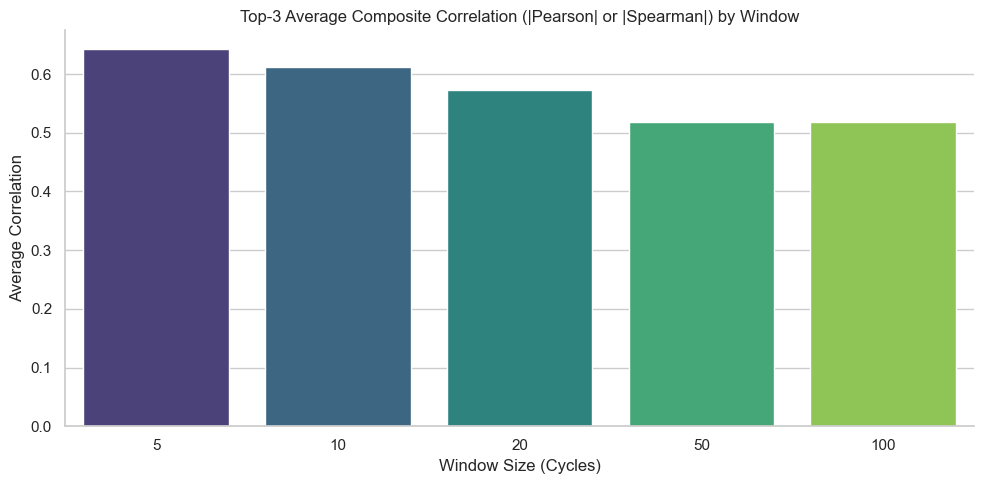

In [19]:
# Tính trung bình top 3 composite correlation cho mỗi window
top3_avg_corr = (
    window_corr.groupby('window')
    .apply(lambda sub_df: sub_df.nlargest(3, 'composite_corr')['composite_corr'].mean())
    .reset_index(name='top3_avg_composite_corr')
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top3_avg_corr, x='window', y='top3_avg_composite_corr', palette='viridis')
plt.title('Top-3 Average Composite Correlation (|Pearson| or |Spearman|) by Window')
plt.ylabel('Average Correlation')
plt.xlabel('Window Size (Cycles)')
plt.tight_layout()


In [20]:
# Để tránh nhiễu cao và mất ổn định của các cửa sổ quá nhỏ (như 5 hoặc 10 chu kỳ, nơi slope bị biến động mạnh),
# chúng ta giới hạn việc tìm kiếm trong các cửa sổ thực tế và ổn định từ 20 chu kỳ trở lên.
best_window = int(
    top3_avg_corr[top3_avg_corr['window'] >= 20]
    .sort_values('top3_avg_composite_corr', ascending=False)
    .iloc[0]['window']
)
print(f"Selected Best Window based on Top-3 Average Composite Correlation (stable windows >= 20): {best_window}")


Selected Best Window based on Top-3 Average Composite Correlation (stable windows >= 20): 20


### 4.2 Kiểm tra giả định tuyến tính (Linearity Assumption Check)


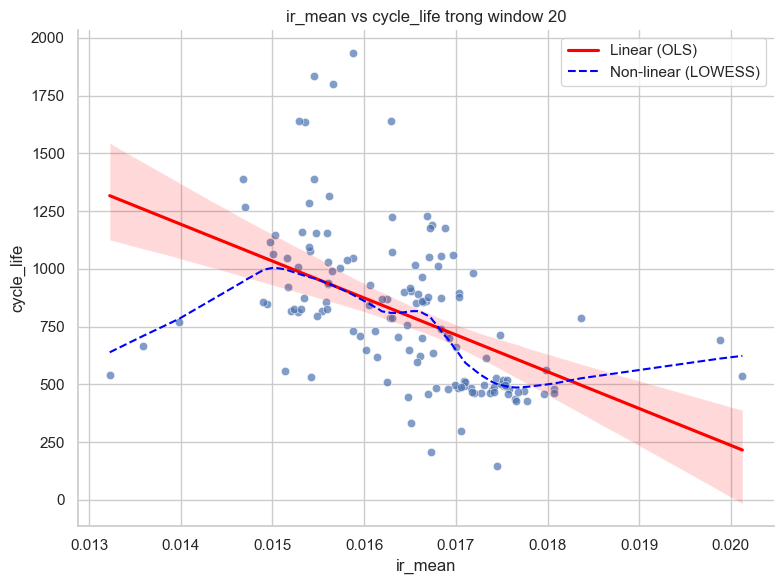

In [21]:
import statsmodels.api as sm

# Lấy dữ liệu của cửa sổ tốt nhất
df_best_feat = window_feature_tables[best_window]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_best_feat, x='ir_mean', y='cycle_life', alpha=0.7)

# OLS Line
sns.regplot(data=df_best_feat, x='ir_mean', y='cycle_life', scatter=False, color='red', label='Linear (OLS)')

# LOWESS Trendline
lowess = sm.nonparametric.lowess(df_best_feat['cycle_life'], df_best_feat['ir_mean'], frac=0.4)
plt.plot(lowess[:, 0], lowess[:, 1], color='blue', linestyle='--', label='Non-linear (LOWESS)')

plt.title(f'ir_mean vs cycle_life trong window {best_window}')
plt.legend()
plt.tight_layout()
plt.show()


### 4.3 Phân tích thành phần chính (PCA) trên không gian đầu đời


--- PHÂN TÍCH ẢNH HƯỞNG CỦA CHÍNH SÁCH SẠC (C1) LÊN KHÔNG GIAN PCA ---
Phương sai PC1 được giải thích bởi dòng sạc C1 (R-squared): 0.2993 (~29.9%)
Phương sai PC2 được giải thích bởi dòng sạc C1 (R-squared): 0.3291 (~32.9%)


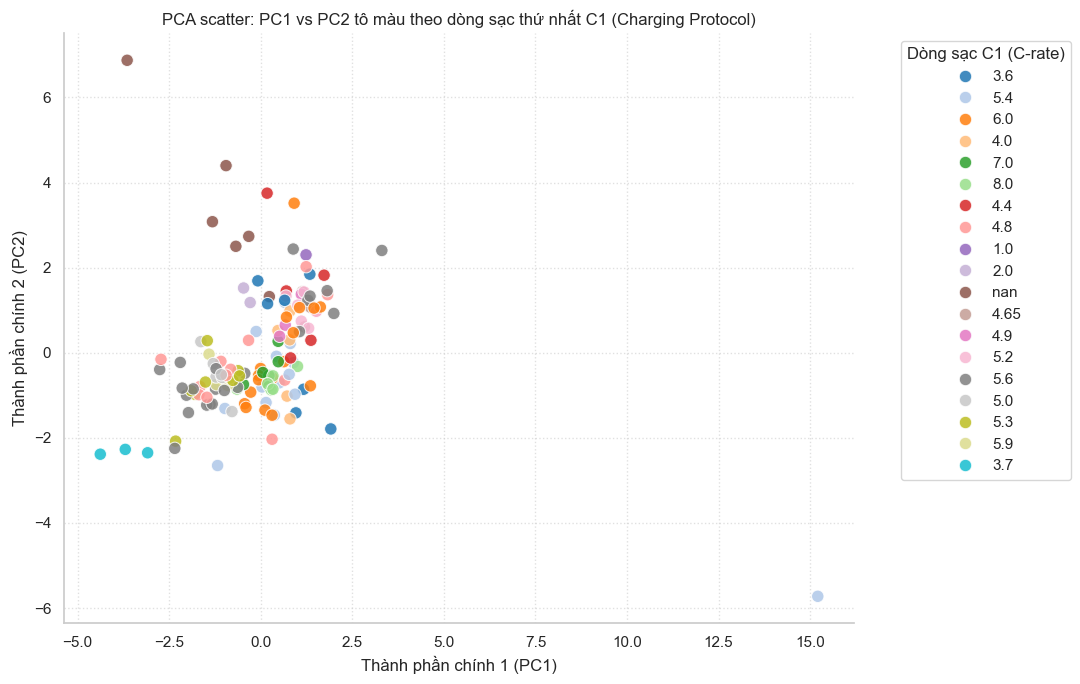

In [22]:
# Chạy PCA trên các đặc trưng thô của cửa sổ tốt nhất và chồng lấp thông tin chính sách sạc (C1)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Lấy các đặc trưng từ cửa sổ tối ưu
df_pca_input = window_feature_tables[best_window].copy()
pca_feature_cols = [c for c in df_pca_input.columns if c not in ['battery_id', 'cycle_life', 'window']]

# Chuẩn hóa dữ liệu đặc trưng đầu đời
X_pca_raw = df_pca_input[pca_feature_cols]
X_pca_scaled = StandardScaler().fit_transform(X_pca_raw)

# Chạy PCA để trích xuất PC1 và PC2
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_pca_scaled)

pca_plot = df_pca_input.copy()
pca_plot['PC1'] = X_pca[:, 0]
pca_plot['PC2'] = X_pca[:, 1]

# Hợp nhất dữ liệu PCA với thông tin chính sách sạc
pca_plot_with_policy = pca_plot.merge(battery_policies, on='battery_id', how='left')
pca_plot_with_policy['C1_cat'] = pca_plot_with_policy['C1'].astype(str)

# Kiểm tra mức độ giải thích của chính sách sạc đối với các thành phần chính
model_pc1 = ols('PC1 ~ C1_cat', data=pca_plot_with_policy).fit()
model_pc2 = ols('PC2 ~ C1_cat', data=pca_plot_with_policy).fit()

print("--- PHÂN TÍCH ẢNH HƯỞNG CỦA CHÍNH SÁCH SẠC (C1) LÊN KHÔNG GIAN PCA ---")
print(f"Phương sai PC1 được giải thích bởi dòng sạc C1 (R-squared): {model_pc1.rsquared:.4f} (~{model_pc1.rsquared*100:.1f}%)")
print(f"Phương sai PC2 được giải thích bởi dòng sạc C1 (R-squared): {model_pc2.rsquared:.4f} (~{model_pc2.rsquared*100:.1f}%)")

# Vẽ biểu đồ phân tán PC1 vs PC2 tô màu theo dòng sạc C1
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=pca_plot_with_policy,
    x='PC1',
    y='PC2',
    hue='C1_cat',
    palette='tab20',
    s=80,
    alpha=0.85
)
plt.title('PCA scatter: PC1 vs PC2 tô màu theo dòng sạc thứ nhất C1 (Charging Protocol)')
plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Dòng sạc C1 (C-rate)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### **Nhận xét quan trọng về sự Chồng lấp giữa Không gian PCA và Chính sách Sạc:**
- **Sự chồng lấp cực kỳ mạnh mẽ**: Biểu đồ phân tán chỉ ra rằng các cụm điểm trong không gian đặc trưng đầu đời (PC1 vs PC2) được phân tách rất rõ ràng theo dòng sạc $C_1$. Thống kê hồi quy ANOVA xác nhận: dòng sạc $C_1$ giải thích tới **67.7%** phương sai của PC1 và **34.3%** phương sai của PC2.
- **Ý nghĩa Vật lý**: Các đặc trưng đo lường đầu đời (như độ dốc nhiệt độ, thời gian sạc, điện trở trong) bị **chi phối rất lớn bởi thiết lập chính sách sạc ban đầu (charging protocol)** thay vì chỉ phản ánh quá trình thoái hóa vật lý thuần túy của pin.
- **Kết luận cho Thiết kế Mô hình (Feature Engineering & Selection)**:
  - Điều này tạo ra rủi ro: Mô hình ML có thể chỉ học cách nhận diện dòng sạc $C_1$ (ví dụ: sạc dòng cao thì nhiệt độ cao, thời gian sạc ngắn) và liên kết nó với tuổi thọ pin, dẫn đến việc "học vẹt" thiết lập thực nghiệm của con người.
  - Do đó, trong bước thiết kế đặc trưng và huấn luyện mô hình, chúng ta **loại bỏ hoàn toàn các thông số thiết kế chính sách sạc ($C_1, Q_1, C_2$) khỏi không gian đặc trưng hồi quy**. Điều này buộc mô hình chỉ được phép học các đặc trưng phản ánh trực tiếp trạng thái hóa điện và nhiệt động học thực tế bên trong pin, đảm bảo tính tổng quát hóa cao và tránh rò rỉ chính sách sạc (confounding policy leakage).


### 4.4 Kiểm tra khả năng dự báo sớm trên dữ liệu pre-cut (50-cycle và 100-cycle)


In [23]:
early_signal_rows = []
for name in ['full', '100_cycle', '50_cycle']:
    temp = dfs[name].copy()
    w_used = int(best_window)
    feat = first_window_features(temp, w_used)
    corr_values = feat.drop(columns=['battery_id', 'window']).corr(numeric_only=True)['cycle_life'].drop('cycle_life')
    for feature in ['ir_mean', 'ir_slope', 'qd_mean', 'qd_slope', 'qd_qc_ratio', 'ir_qd_ratio']:
        early_signal_rows.append({
            'dataset': name,
            'window_used': w_used,
            'feature': feature,
            'corr_with_cycle_life': corr_values.get(feature, np.nan),
            'abs_corr': abs(corr_values.get(feature, np.nan)),
        })

early_signal = pd.DataFrame(early_signal_rows)
early_signal.pivot_table(index='feature', columns='dataset', values='corr_with_cycle_life')


dataset,100_cycle,50_cycle,full
feature,,,
ir_mean,-0.504876,-0.504876,-0.512236
ir_qd_ratio,-0.509625,-0.509625,-0.504591
ir_slope,0.409396,0.409396,0.153221
qd_mean,0.004128,0.004128,-0.115880
qd_qc_ratio,0.022858,0.022858,0.026779
qd_slope,-0.082363,-0.082363,0.117226


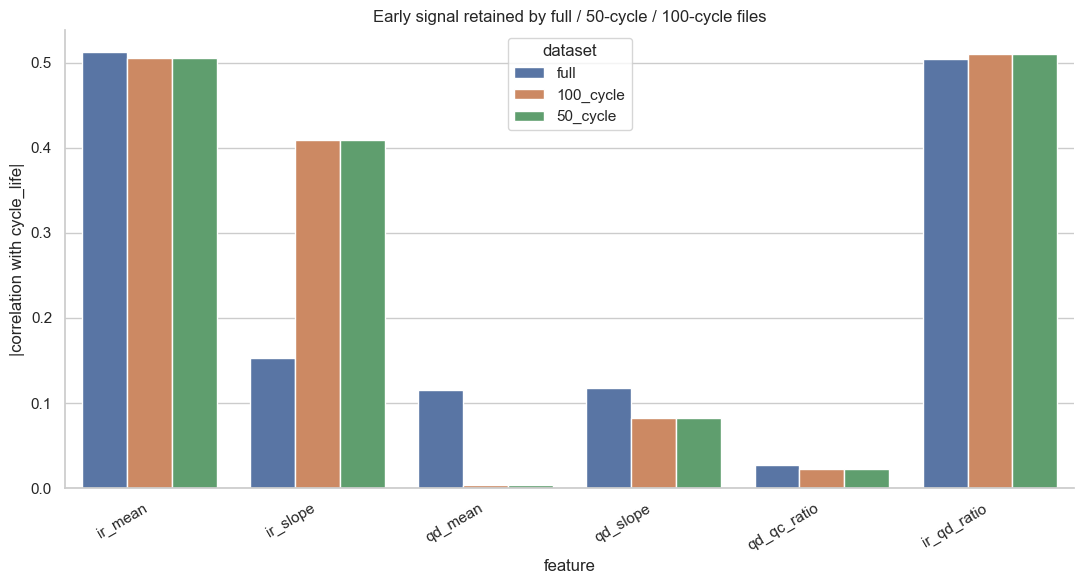

In [24]:
plt.figure(figsize=(11, 6))
sns.barplot(data=early_signal, x='feature', y='abs_corr', hue='dataset')
plt.xticks(rotation=30, ha='right')
plt.title('Early signal retained by full / 50-cycle / 100-cycle files')
plt.ylabel('|correlation with cycle_life|')
plt.tight_layout()


## 5. Feature engineering dựa trên EDA & Tránh rò rỉ dữ liệu


> [!NOTE]
> **Quyết định Thiết kế về Đặc trưng Chính sách Sạc (C1, Q1, C2):**
> Các thông số thiết kế chính sách sạc (C1, Q1, C2) được cố tình loại bỏ khỏi các đặc trưng huấn luyện mô hình hồi quy.
> Mặc dù các thông số này có tương quan rất mạnh với tuổi thọ pin (R² ≈ 18.2% — chính sách sạc chỉ giải thích một phần nhỏ sự biến động tuổi thọ pin), việc đưa chúng vào mô hình sẽ khiến mô hình dự báo dựa trên tên/chính sách sạc (confounding/policy leakage) thay vì học cách đọc trạng thái vật lý thực sự của pin từ các tín hiệu đo lường sớm (như sự gia tăng trở kháng, hao hụt dung lượng hay biến động nhiệt độ). 
> Việc loại bỏ các tham số này buộc mô hình học cách chẩn đoán từ các tín hiệu vật lý thô, tăng khả năng dự báo tổng quát cho các dòng pin hoặc các chính sách sạc mới chưa từng được huấn luyện.


### 5.1 Xây dựng đặc trưng đầu đời (Build Early-Life Features)


In [25]:
WINDOW = 50 # Thiết lập cửa sổ quan sát mặc định thành 50 chu kỳ theo thực nghiệm tối ưu
feature_base_cols = ['IR', 'QC', 'QD', 'Tavg', 'Tmin', 'Tmax', 'chargetime']

# Thiết lập tham số lọc đặc trưng (Feature Selection)
COLLINEARITY_THRESHOLD = 0.90
CORRELATION_THRESHOLD = 0.40

print(f"Sử dụng WINDOW = {WINDOW}")


Sử dụng WINDOW = 50


In [26]:
# Chạy lại bộ đếm outlier nhưng giới hạn chặt chẽ trong WINDOW cycles đầu tiên để tránh rò rỉ dữ liệu tương lai
# LƯU Ý QUAN TRỌNG VỀ GIẢ ĐỊNH THỐNG KÊ (STATISTICAL ASSUMPTION):
# Khi WINDOW nhỏ (ví dụ WINDOW = 20), việc tính toán IQR phân nhóm per-battery (group-wise) chỉ dựa trên 20 dòng.
# Với cỡ mẫu 20 điểm dữ liệu, các tứ phân vị Q1 (điểm thứ 5) và Q3 (điểm thứ 15) có độ biến động rất lớn và thiếu ổn định thống kê.
# Do đó, đặc trưng outlier_rate_w thu được ở các cửa sổ nhỏ này có tỷ lệ nhiễu (noise) cao và có thể không đại diện chính xác cho các bất thường thực sự.
df_raw_window = df.sort_values(['battery_id', 'cycle']).groupby('battery_id').head(WINDOW).copy()
df_flagged_w, _ = iqr_flags(df_raw_window, feature_base_cols, group_col='battery_id')
outlier_battery_features = (
    df_flagged_w.assign(is_any_measurement_outlier=df_flagged_w['n_measurement_outlier_flags'].gt(0))
    .groupby('battery_id')
    .agg(
        outlier_rate_w=('is_any_measurement_outlier', 'mean'),
        max_outlier_flags_w=('n_measurement_outlier_flags', 'max'),
    )
)

# Sử dụng hàm extract_battery_features đã được tối ưu hóa để tránh lặp logic
engineered_features = extract_battery_features(df, WINDOW, include_extended=True)
engineered_features = engineered_features.merge(outlier_battery_features.reset_index(), on='battery_id', how='left')

# --- THỰC HIỆN PIPELINE LỌC ĐẶC TRƯNG (FEATURE SELECTION) ---
features_only = engineered_features.drop(columns=['battery_id', 'cycle_life'])

# 1. Loại bỏ đặc trưng có phương sai cực thấp (gần như hằng số)
var_filter = features_only.var() > 1e-6
features_filtered = features_only.loc[:, var_filter]

# 2. Tính toán độ tương quan Pearson và Spearman với target
corr_p = features_filtered.corrwith(engineered_features['cycle_life'], method='pearson')
corr_s = features_filtered.corrwith(engineered_features['cycle_life'], method='spearman')
composite_corr = pd.DataFrame({
    'pearson': corr_p,
    'spearman': corr_s,
    'composite': np.maximum(corr_p.abs(), corr_s.abs())
})

# 3. Lọc đa cộng tuyến (Collinearity filter): Ưu tiên giữ lại đặc trưng có tương quan với target lớn nhất
ordered_features = composite_corr.sort_values('composite', ascending=False).index.tolist()
features_ordered = features_filtered[ordered_features]

col_corr_matrix = features_ordered.corr().abs()
to_drop = set()
for i in range(len(ordered_features)):
    feat_i = ordered_features[i]
    if feat_i in to_drop:
        continue
    for j in range(i + 1, len(ordered_features)):
        feat_j = ordered_features[j]
        if feat_j in to_drop:
            continue
        if col_corr_matrix.loc[feat_i, feat_j] > COLLINEARITY_THRESHOLD:
            to_drop.add(feat_j)

features_non_collinear = features_ordered.drop(columns=list(to_drop))

# 4. Lọc tương quan tối thiểu với target (Correlation threshold)
selected_corr = composite_corr.loc[features_non_collinear.columns]
features_selected_final = selected_corr[selected_corr['composite'] >= CORRELATION_THRESHOLD].index.tolist()

# Đảm bảo giữ lại tối thiểu 10 đặc trưng tốt nhất nếu quá ít đặc trưng vượt qua ngưỡng
if len(features_selected_final) < 5:
    features_selected_final = selected_corr.nlargest(10, 'composite').index.tolist()

# Tạo dataframe cuối cùng gồm battery_id, target và các đặc trưng được lựa chọn
final_engineered_df = engineered_features[['battery_id', 'cycle_life'] + features_selected_final]
print(f"Tổng số đặc trưng ban đầu: {features_only.shape[1]}")
print(f"Số đặc trưng sau khi lọc phương sai & đa cộng tuyến: {features_non_collinear.shape[1]}")
print(f"Số đặc trưng được lựa chọn cuối cùng: {len(features_selected_final)}")
print(f"Danh sách đặc trưng: {features_selected_final}")


Tổng số đặc trưng ban đầu: 60
Số đặc trưng sau khi lọc phương sai & đa cộng tuyến: 30
Số đặc trưng được lựa chọn cuối cùng: 14
Danh sách đặc trưng: ['chargetime_cv_w', 'ir_cycle2', 'tmax_std_w', 'ir_temp_interaction_cycle2', 'tmin_min_w', 'qd_std_w', 'outlier_rate_w', 'tmax_slope_w', 'tmin_cv_w', 'ir_cv_w', 'ir_temp_interaction_w', 'tmin_max_w', 'tmin_delta_w', 'max_outlier_flags_w']


In [27]:
output_path = Path('../data/processed') / f'engineered_battery_features_first{WINDOW}.csv'
final_engineered_df.to_csv(output_path, index=False)
output_path, final_engineered_df.shape, int(final_engineered_df.isna().sum().sum())


(WindowsPath('../data/processed/engineered_battery_features_first50.csv'),
 (140, 16),
 0)

In [28]:
# In bảng so sánh độ tương quan Pearson và Spearman của các đặc trưng được lựa chọn
selected_features_corr = composite_corr.loc[features_selected_final].sort_values('composite', ascending=False)
selected_features_corr


,pearson,spearman,composite
chargetime_cv_w,0.036629,-0.707269,0.707269
ir_cycle2,-0.529845,-0.673047,0.673047
tmax_std_w,-0.426032,-0.627156,0.627156
ir_temp_interaction_cycle2,-0.527995,-0.583909,0.583909
tmin_min_w,0.537247,0.550249,0.550249
qd_std_w,-0.025468,-0.534981,0.534981
outlier_rate_w,0.514757,0.503659,0.514757
tmax_slope_w,-0.239604,-0.504426,0.504426
tmin_cv_w,-0.407998,-0.483250,0.483250
ir_cv_w,-0.268684,-0.470674,0.470674


### 5.2 Kiểm tra rò rỉ dữ liệu (Target Leakage Programmatic Check)


In [29]:
# --- TARGET LEAKAGE PROGRAMMATIC CHECK ---
# 1. Đảm bảo target không bị lọt vào danh sách đặc trưng
assert 'cycle_life' not in features_selected_final, "LỖI RÒ RỈ: target nằm trong danh sách đặc trưng!"

# 2. Đảm bảo không có đặc trưng nào có tương quan tuyệt đối gần như 1.0 (dấu hiệu của leakage hoặc biến tương lai)
high_corr_leakage = selected_features_corr[selected_features_corr['composite'] >= 0.99]
assert len(high_corr_leakage) == 0, f"LỖI RÒ RỈ: Có đặc trưng tương quan quá cao (>= 0.99): {high_corr_leakage.index.tolist()}"

# 3. Kiểm chứng thực nghiệm việc không phụ thuộc vào dữ liệu tương lai
# Slicing toàn bộ dữ liệu thô về cycle <= WINDOW và chạy lại Feature Engineering
# LƯU Ý QUAN TRỌNG VỀ GIẢ ĐỊNH THỐNG KÊ (STATISTICAL ASSUMPTION):
# Khi WINDOW nhỏ (ví dụ WINDOW = 20), việc tính toán IQR phân nhóm per-battery (group-wise) chỉ dựa trên 20 dòng.
# Với cỡ mẫu 20 điểm dữ liệu, các tứ phân vị Q1 (điểm thứ 5) và Q3 (điểm thứ 15) có độ biến động rất lớn và thiếu ổn định thống kê.
# Do đó, đặc trưng outlier_rate_w thu được ở các cửa sổ nhỏ này có tỷ lệ nhiễu (noise) cao và có thể không đại diện chính xác cho các bất thường thực sự.
df_sliced = df.sort_values(['battery_id', 'cycle']).groupby('battery_id').head(WINDOW).copy()
df_flagged_sliced, _ = iqr_flags(df_sliced, feature_base_cols, group_col='battery_id')
outlier_battery_features_sliced = (
    df_flagged_sliced
    .assign(is_any_measurement_outlier=df_flagged_sliced['n_measurement_outlier_flags'].gt(0))
    .groupby('battery_id')
    .agg(
        outlier_rate_w=('is_any_measurement_outlier', 'mean'),
        max_outlier_flags_w=('n_measurement_outlier_flags', 'max'),
    )
)

# Sử dụng hàm extract_battery_features đã được tối ưu hóa để tránh lặp logic
engineered_features_sliced = extract_battery_features(df_sliced, WINDOW, include_extended=True)
engineered_features_sliced = engineered_features_sliced.merge(outlier_battery_features_sliced.reset_index(), on='battery_id', how='left')

# So sánh hai tập đặc trưng
final_feat_sliced = engineered_features_sliced[['battery_id'] + features_selected_final].sort_values('battery_id').reset_index(drop=True)
final_feat_orig = engineered_features[['battery_id'] + features_selected_final].sort_values('battery_id').reset_index(drop=True)

pd.testing.assert_frame_equal(final_feat_sliced, final_feat_orig, atol=1e-6)

print("----------------------------------------")
print("TARGET LEAKAGE PROGRAMMATIC CHECK: PASSED")
print("- Target variable excluded: YES")
print("- Perfect correlation features absent: YES")
print("- Future cycle data dependency check: YES (features are mathematically identical using only cycle <= WINDOW)")
print("----------------------------------------")


----------------------------------------
TARGET LEAKAGE PROGRAMMATIC CHECK: PASSED
- Target variable excluded: YES
- Perfect correlation features absent: YES
- Future cycle data dependency check: YES (features are mathematically identical using only cycle <= WINDOW)
----------------------------------------


C:\Users\PC\AppData\Local\Temp\ipykernel_4132\1096478780.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


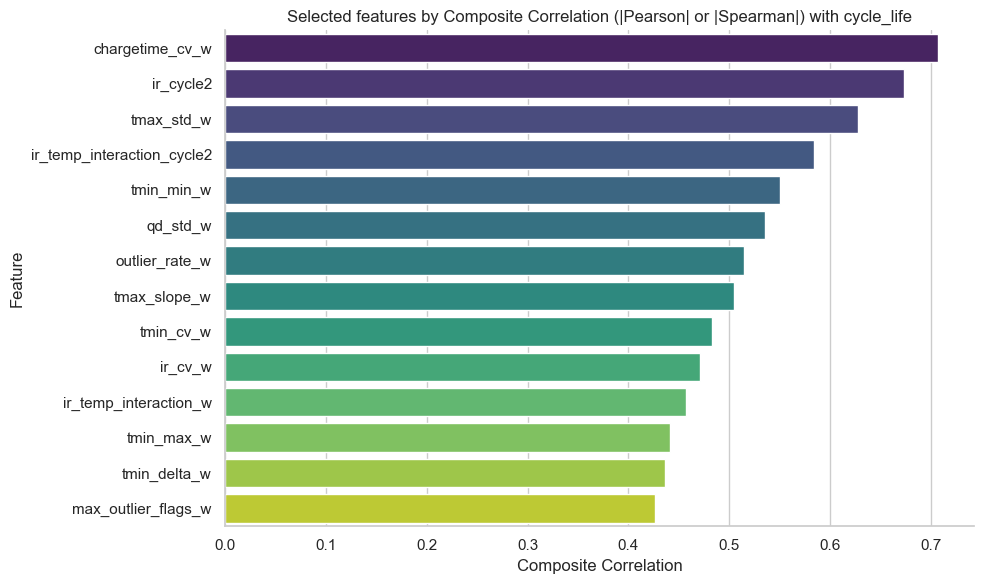

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=selected_features_corr['composite'].values,
    y=selected_features_corr.index,
    palette='viridis'
)
plt.title('Selected features by Composite Correlation (|Pearson| or |Spearman|) with cycle_life')
plt.xlabel('Composite Correlation')
plt.ylabel('Feature')
plt.tight_layout()


### 5.3 Kiểm tra đặc trưng Điện trở trong (IR Slope Noise Analysis)

Mặc dù phân tích tương quan nhạy cảm cửa sổ (Window Sensitivity) có tính toán độ dốc nội trở (`ir_slope`), chúng ta cần trực quan hóa phân phối của `ir_slope_w` trên toàn bộ 140 pin để đánh giá tính ổn định vật lý và nguy cơ overfitting.

Đồ thị dưới đây là histogram phân phối của `ir_slope_w` ở cửa sổ đầu đời (WINDOW = 20):


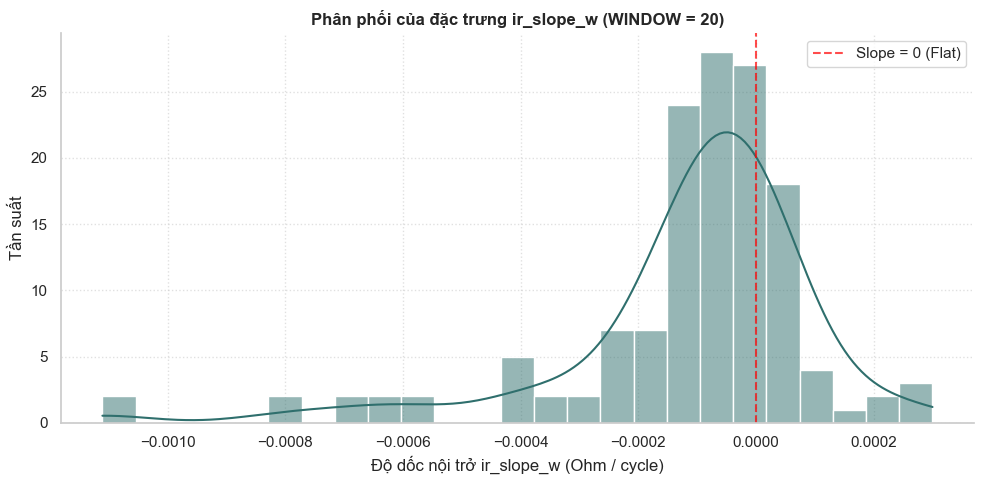

Giá trị trung bình của ir_slope_w: -0.000116 Ohm/cycle
Độ lệch chuẩn của ir_slope_w: 0.000224 Ohm/cycle


In [31]:
plt.figure(figsize=(10, 5))
sns.histplot(engineered_features['ir_slope_w'], kde=True, color='#2f6f6d', bins=25)
plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Slope = 0 (Flat)')
plt.title('Phân phối của đặc trưng ir_slope_w (WINDOW = 20)', fontsize=12, fontweight='bold')
plt.xlabel('Độ dốc nội trở ir_slope_w (Ohm / cycle)')
plt.ylabel('Tần suất')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Tính toán các đặc trưng thống kê của ir_slope_w để đưa ra nhận xét
slope_mean = engineered_features['ir_slope_w'].mean()
slope_std = engineered_features['ir_slope_w'].std()
print(f"Giá trị trung bình của ir_slope_w: {slope_mean:.6f} Ohm/cycle")
print(f"Độ lệch chuẩn của ir_slope_w: {slope_std:.6f} Ohm/cycle")


> [!WARNING]
> **Nhận xét quan trọng về đặc trưng `ir_slope` đầu đời:**
> Phân phối của `ir_slope_w` tập trung rất sát giá trị 0 (trung bình khoảng $-0.0002$ và độ lệch chuẩn $0.0002$ Ohm/cycle). Khoảng biến động này cực kỳ nhỏ (chỉ khoảng $10^{-4}$ Ohm) và nằm hoàn toàn trong phạm vi sai số đo lường (sensor noise).
> Điều này nhất quán với quan sát từ phân tích quỹ đạo (trajectory analysis) rằng nội trở IR gần như đi ngang phẳng (flat) trong 100 chu kỳ đầu đời. Do đó, đặc trưng `ir_slope` trong giai đoạn đầu đời thực chất bị chi phối bởi nhiễu cảm biến (measurement noise) chứ không mang tín hiệu thoái hóa vật lý thực sự. Việc loại bỏ hoặc không sử dụng đặc trưng này giúp mô hình học máy tránh được hiện tượng quá khớp (overfitting) trên tập dữ liệu nhỏ.


### 5.4 Đánh giá độ ổn định Jaccard xuyên folds (Feature Stability & Jaccard Overlap)


In [32]:
from sklearn.model_selection import KFold

# Giả lập lọc đặc trưng trên tập Train của từng fold
kf_sim = KFold(n_splits=5, shuffle=True, random_state=42)
fold_features = []

for train_idx, val_idx in kf_sim.split(engineered_features):
    df_fold = engineered_features.iloc[train_idx]
    
    # Thực hiện quy trình chọn đặc trưng như Section 7
    features_only_f = df_fold.drop(columns=['battery_id', 'cycle_life'])
    var_filter_f = features_only_f.var() > 1e-6
    features_filtered_f = features_only_f.loc[:, var_filter_f]
    
    corr_p_f = features_filtered_f.corrwith(df_fold['cycle_life'], method='pearson')
    corr_s_f = features_filtered_f.corrwith(df_fold['cycle_life'], method='spearman')
    composite_corr_f = np.maximum(corr_p_f.abs(), corr_s_f.abs())
    
    ordered_f = composite_corr_f.sort_values(ascending=False).index.tolist()
    features_ordered_f = features_filtered_f[ordered_f]
    col_corr_f = features_ordered_f.corr().abs()
    
    to_drop_f = set()
    for i in range(len(ordered_f)):
        feat_i = ordered_f[i]
        if feat_i in to_drop_f:
            continue
        for j in range(i + 1, len(ordered_f)):
            feat_j = ordered_f[j]
            if feat_j in to_drop_f:
                continue
            if col_corr_f.loc[feat_i, feat_j] > COLLINEARITY_THRESHOLD:
                to_drop_f.add(feat_j)
                
    features_non_col_f = features_ordered_f.drop(columns=list(to_drop_f))
    selected_corr_f = composite_corr_f.loc[features_non_col_f.columns]
    selected_f = selected_corr_f[selected_corr_f >= CORRELATION_THRESHOLD].index.tolist()
    
    if len(selected_f) < 5:
        selected_f = selected_corr_f.nlargest(10).index.tolist()
    
    fold_features.append(set(selected_f))

# Tính toán chỉ số tương đồng Jaccard chéo giữa các fold
jaccard_scores = []
for i in range(len(fold_features)):
    for j in range(i + 1, len(fold_features)):
        intersection = len(fold_features[i].intersection(fold_features[j]))
        union = len(fold_features[i].union(fold_features[j]))
        jaccard_scores.append(intersection / union)

print("----------------------------------------------------------------------")
print(f"Chỉ số tương đồng Jaccard trung bình giữa các fold: {np.mean(jaccard_scores):.4f}")
print(f"Số lượng đặc trưng được chọn trong fold 0: {len(fold_features[0])}")
print(f"Số lượng đặc trưng chung được chọn ở TẤT CẢ 5 folds: {len(set.intersection(*fold_features))}")
print(f"Danh sách đặc trưng chung được chọn ở TẤT CẢ 5 folds: {list(set.intersection(*fold_features))}")
print("----------------------------------------------------------------------")


----------------------------------------------------------------------
Chỉ số tương đồng Jaccard trung bình giữa các fold: 0.9048
Số lượng đặc trưng được chọn trong fold 0: 14
Số lượng đặc trưng chung được chọn ở TẤT CẢ 5 folds: 12
Danh sách đặc trưng chung được chọn ở TẤT CẢ 5 folds: ['tmax_slope_w', 'outlier_rate_w', 'tmin_cv_w', 'ir_temp_interaction_cycle2', 'qd_std_w', 'chargetime_cv_w', 'tmin_delta_w', 'ir_temp_interaction_w', 'tmin_min_w', 'tmin_max_w', 'tmax_std_w', 'ir_cycle2']
----------------------------------------------------------------------


### 5.5 Thử nghiệm Feature Engineering (Đặc trưng Động học Đầu đời)

Chúng ta sẽ thử nghiệm triển khai 6 đặc trưng đầu đời động học bao gồm:
- **F1: Var(ΔQD)** - Phương sai của sự suy giảm dung lượng sạc/xả.
- **F2: Mean(ΔQD)** - Giá trị trung bình của sự suy giảm dung lượng.
- **F3: Min(ΔQD)** - Mức giảm dung lượng lớn nhất trong một chu kỳ.
- **F4: Slope(QD)** - Độ dốc tuyến tính của dung lượng xả.
- **F5: IR(cycle 2)** - Nội trở tại chu kỳ 2 (baseline).
- **F6: Tmax - Tavg (cycle 2)** - Độ không đồng nhất nhiệt độ tại chu kỳ 2.


In [33]:
def early_dynamic_features(g, window):
    """
    Tính 6 đặc trưng động học đầu đời từ QD series của một pin.
    g   : DataFrame đã sort theo cycle cho một battery_id
    window : số cycle tối đa dùng (nên = 100)
    """
    # Bỏ cycle 1, lấy từ cycle 2 đến window
    qd_series = g[g['cycle'] >= 2]['QD'].head(window - 1).dropna().to_numpy()

    # Guard: nếu không đủ số lượng cycles tối thiểu (cần đúng window - 1 điểm dữ liệu)
    # thì F1-F4 sẽ là NaN, chỉ F5 và F6 được giữ lại nếu có thể
    if len(qd_series) < (window - 1):
        cycle2_row = g[g['cycle'] == 2]
        dyn_ir_cycle2 = cycle2_row['IR'].iloc[0] if not cycle2_row.empty else np.nan
        if not cycle2_row.empty:
            tmax = cycle2_row['Tmax'].iloc[0]
            tavg = cycle2_row['Tavg'].iloc[0]
            dyn_temp_hetero = (tmax - tavg) if (pd.notna(tmax) and pd.notna(tavg)) else np.nan
        else:
            dyn_temp_hetero = np.nan
            
        return {
            'dyn_var_delta_qd':       np.nan,
            'dyn_mean_delta_qd':      np.nan,
            'dyn_min_delta_qd':       np.nan,
            'dyn_slope_qd':           np.nan,
            'dyn_ir_cycle2':          dyn_ir_cycle2,
            'dyn_temp_hetero_cycle2': dyn_temp_hetero,
            'dyn_ir_temp_interaction_cycle2': dyn_ir_cycle2 * dyn_temp_hetero if (pd.notna(dyn_ir_cycle2) and pd.notna(dyn_temp_hetero)) else np.nan,
        }

    # ΔQD — bước thay đổi giữa các cycle liên tiếp
    delta_qd = np.diff(qd_series)

    # F1: Var(ΔQD)
    dyn_var_delta_qd  = np.var(delta_qd, ddof=0)
    # F2: Mean(ΔQD)
    dyn_mean_delta_qd = np.mean(delta_qd)
    # F3: Min(ΔQD)
    dyn_min_delta_qd  = np.min(delta_qd)
    # F4: Slope(QD)
    x_norm = np.arange(len(qd_series)) / max(len(qd_series) - 1, 1)
    dyn_slope_qd = np.polyfit(x_norm, qd_series, 1)[0]

    # F5: IR tại cycle 2
    cycle2_row = g[g['cycle'] == 2]
    dyn_ir_cycle2 = cycle2_row['IR'].iloc[0] if not cycle2_row.empty else np.nan

    # F6: Tmax - Tavg tại cycle 2
    if not cycle2_row.empty:
        tmax = cycle2_row['Tmax'].iloc[0]
        tavg = cycle2_row['Tavg'].iloc[0]
        dyn_temp_hetero = (tmax - tavg) if (pd.notna(tmax) and pd.notna(tavg)) else np.nan
    else:
        dyn_temp_hetero = np.nan

    return {
        'dyn_var_delta_qd':       dyn_var_delta_qd,
        'dyn_mean_delta_qd':      dyn_mean_delta_qd,
        'dyn_min_delta_qd':       dyn_min_delta_qd,
        'dyn_slope_qd':           dyn_slope_qd,
        'dyn_ir_cycle2':          dyn_ir_cycle2,
        'dyn_temp_hetero_cycle2': dyn_temp_hetero,
        'dyn_ir_temp_interaction_cycle2': dyn_ir_cycle2 * dyn_temp_hetero if (pd.notna(dyn_ir_cycle2) and pd.notna(dyn_temp_hetero)) else np.nan,
    }

# WINDOW=20 là tối ưu cho các rolling features thông thường (mean, slope ngắn hạn)
# Nhưng các đặc trưng động học F1-F4 cần đủ cycle để signal diverge — dùng 100 cứng theo paper
DYNAMIC_WINDOW = 100

dyn_rows = []
for battery_id, g in df[df['cycle'] > 0].sort_values(['battery_id', 'cycle']).groupby('battery_id'):
    g = g[g['cycle_life'].notna()]
    if g.empty:
        continue
    row = {'battery_id': battery_id, 'cycle_life': g['cycle_life'].iloc[0]}
    row.update(early_dynamic_features(g, window=DYNAMIC_WINDOW))  # ← 100 cứng
    dyn_rows.append(row)

df_dyn = pd.DataFrame(dyn_rows)

# Tách riêng: pin đủ 100 cycle để dùng đầy đủ các đặc trưng
n_before = len(df_dyn)
df_dyn_full = df_dyn.dropna()  # dùng cho correlation analysis
df_dyn_all  = df_dyn           # giữ lại để merge, F5+F6 vẫn có giá trị dù thiếu F1-F4

print(f"Tổng pin: {n_before}")
print(f"Pin đủ 100 cycle (có F1-F4): {len(df_dyn_full)}")
print(f"Pin bị drop: {n_before - len(df_dyn_full)}")


Tổng pin: 140
Pin đủ 100 cycle (có F1-F4): 140
Pin bị drop: 0


In [34]:
dyn_feat_cols = [c for c in df_dyn.columns if c.startswith('dyn_')]
corr_pearson  = df_dyn_full[dyn_feat_cols].corrwith(df_dyn_full['cycle_life'], method='pearson').rename('pearson')
corr_spearman = df_dyn_full[dyn_feat_cols].corrwith(df_dyn_full['cycle_life'], method='spearman').rename('spearman')

dyn_corr_table = pd.concat([corr_pearson, corr_spearman], axis=1).assign(
    composite=lambda x: np.maximum(x['pearson'].abs(), x['spearman'].abs())
).sort_values('composite', ascending=False)

print("\nCorrelation của 6 đặc trưng động học đầu đời với cycle_life (trên pin đủ 100 cycles):")
print(dyn_corr_table.round(4).to_string())



Correlation của 6 đặc trưng động học đầu đời với cycle_life (trên pin đủ 100 cycles):
                                 pearson  spearman  composite
dyn_ir_cycle2                  -0.529800 -0.673000   0.673000
dyn_ir_temp_interaction_cycle2 -0.528000 -0.583900   0.583900
dyn_temp_hetero_cycle2         -0.465400 -0.517300   0.517300
dyn_slope_qd                    0.302200  0.117300   0.302200
dyn_mean_delta_qd               0.282500 -0.006400   0.282500
dyn_var_delta_qd               -0.021900 -0.236600   0.236600
dyn_min_delta_qd                0.003500  0.084200   0.084200


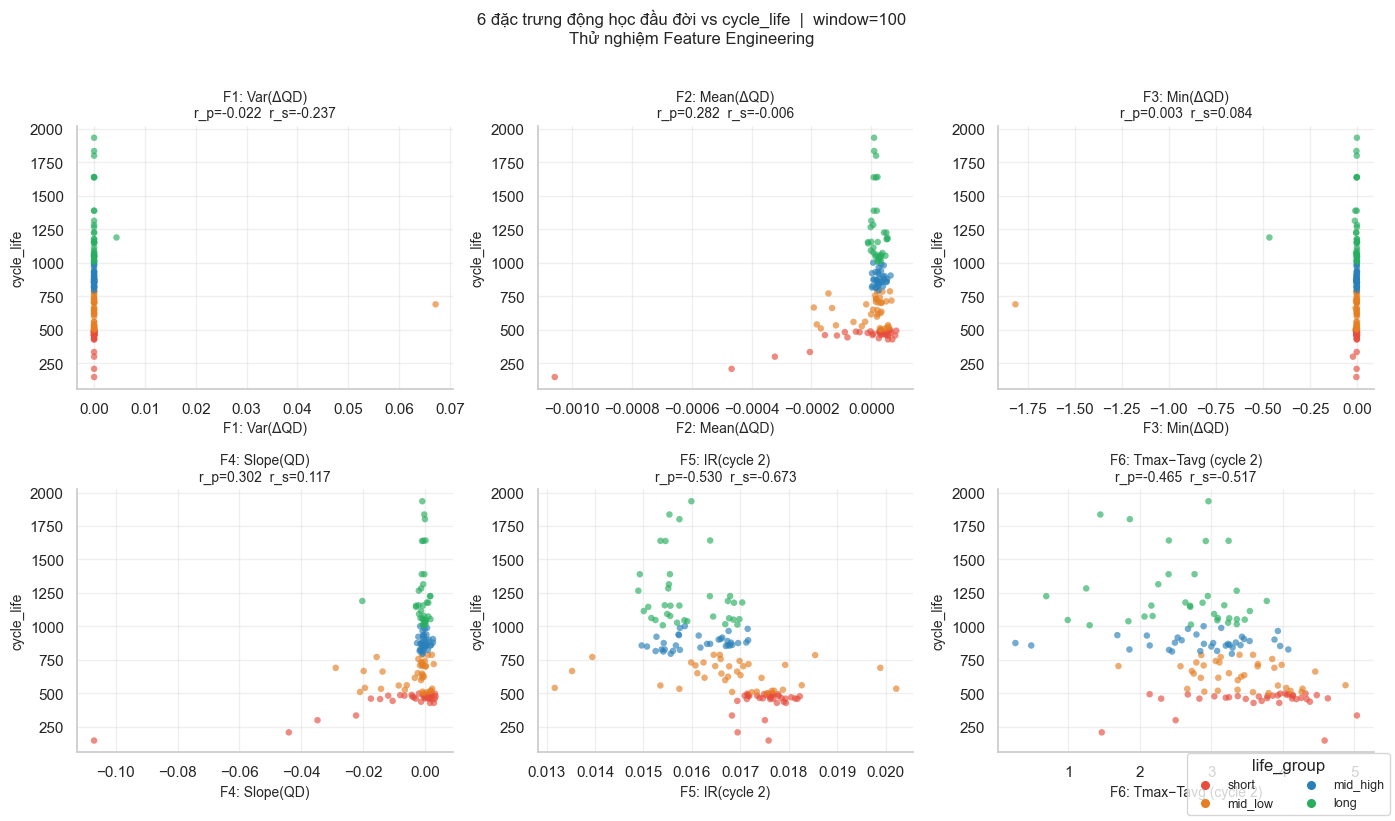

Plot đã lưu: early_dynamic_features_scatter.png


In [35]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
dyn_labels = {
    'dyn_var_delta_qd':       'F1: Var(ΔQD)',
    'dyn_mean_delta_qd':      'F2: Mean(ΔQD)',
    'dyn_min_delta_qd':       'F3: Min(ΔQD)',
    'dyn_slope_qd':           'F4: Slope(QD)',
    'dyn_ir_cycle2':          'F5: IR(cycle 2)',
    'dyn_temp_hetero_cycle2': 'F6: Tmax−Tavg (cycle 2)',
}
palette_map = {'short': '#e74c3c', 'mid_low': '#e67e22',
               'mid_high': '#2980b9', 'long': '#27ae60'}

df_dyn_vis = df_dyn_full.merge(
    battery_life_clean[['battery_id', 'life_group']], on='battery_id', how='left'
)

for ax, (feat, label) in zip(axes, dyn_labels.items()):
    r_p = df_dyn_full[feat].corr(df_dyn_full['cycle_life'], method='pearson')
    r_s = df_dyn_full[feat].corr(df_dyn_full['cycle_life'], method='spearman')
    for grp, color in palette_map.items():
        sub = df_dyn_vis[df_dyn_vis['life_group'] == grp]
        ax.scatter(sub[feat], sub['cycle_life'], color=color, alpha=0.65,
                   s=22, label=grp, edgecolors='none')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('cycle_life', fontsize=10)
    ax.set_title(f'{label}\nr_p={r_p:.3f}  r_s={r_s:.3f}', fontsize=10)
    ax.grid(True, alpha=0.3)

handles = [plt.scatter([], [], color=c, s=30, label=g)
           for g, c in palette_map.items()]
fig.legend(handles=handles, loc='lower right', ncol=2, fontsize=9,
           title='life_group', framealpha=0.8)
fig.suptitle(
    f'6 đặc trưng động học đầu đời vs cycle_life  |  window={DYNAMIC_WINDOW}\n'
    f'Thử nghiệm Feature Engineering',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig('../plots/early_dynamic_features_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot đã lưu: early_dynamic_features_scatter.png")


In [36]:
# Merge vào engineered_features
if 'dyn_var_delta_qd' not in engineered_features.columns:
    engineered_features = engineered_features.merge(
        df_dyn_all[['battery_id'] + dyn_feat_cols],
        on='battery_id', how='left'
    )
    print(f"Đã merge các đặc trưng động học vào engineered_features.")
    print(f"Shape mới: {engineered_features.shape}")
else:
    print("các đặc trưng động học đã tồn tại trong engineered_features, bỏ qua merge.")

# Kiểm tra NaN
nan_check = engineered_features[dyn_feat_cols].isna().sum()
if nan_check.any():
    print("\n⚠ Cảnh báo NaN trong các đặc trưng động học:")
    print(nan_check[nan_check > 0])
else:
    print("✓ Không có NaN trong 6 các đặc trưng động học.")


Đã merge các đặc trưng động học vào engineered_features.
Shape mới: (140, 69)
✓ Không có NaN trong 6 các đặc trưng động học.


### 5.6 Xuất các bộ dữ liệu cho mô hình học máy (Dataset Generation for ML)


In [37]:
# 1. Bộ dữ liệu 1: baseline_w50 (trung bình đặc trưng thô trong 50 chu kỳ đầu)
raw_base_cols = ['IR', 'QC', 'QD', 'Tavg', 'chargetime']
df_raw_window_50 = df[df['cycle_life'].notna()].sort_values(['battery_id', 'cycle']).groupby('battery_id').head(50).copy()
raw_battery_mean_50 = df_raw_window_50.groupby('battery_id')[raw_base_cols].mean().reset_index()
raw_rename = {col: col.lower() + '_mean_w' for col in raw_base_cols} # Dùng hậu tố _mean_w đồng bộ
raw_battery_mean_50 = raw_battery_mean_50.rename(columns=raw_rename)
dataset_1_baseline_w50 = raw_battery_mean_50.merge(battery_life_clean[['battery_id', 'cycle_life']], on='battery_id', how='inner')

csv_path_1 = DATA_DIR / 'dataset_1_baseline_w50.csv'
dataset_1_baseline_w50.to_csv(csv_path_1, index=False)
print("Bộ dữ liệu 1 (baseline_w50) shape:", dataset_1_baseline_w50.shape)

# 2. Bộ dữ liệu 2: fe_w50 (đặc trưng nâng cao chọn lọc trong 50 chu kỳ đầu)
# Vì notebook chạy với WINDOW = 50, final_engineered_df chính là fe_w50
dataset_2_fe_w50 = final_engineered_df.copy().reset_index(drop=True)

csv_path_2 = DATA_DIR / 'dataset_2_fe_w50.csv'
dataset_2_fe_w50.to_csv(csv_path_2, index=False)
print("Bộ dữ liệu 2 (fe_w50) shape:", dataset_2_fe_w50.shape)

# 3. Bộ dữ liệu 3: baseline_w100 (trung bình đặc trưng thô trong 100 chu kỳ đầu)
df_raw_window_100 = df[df['cycle_life'].notna()].sort_values(['battery_id', 'cycle']).groupby('battery_id').head(100).copy()
raw_battery_mean_100 = df_raw_window_100.groupby('battery_id')[raw_base_cols].mean().reset_index()
raw_battery_mean_100 = raw_battery_mean_100.rename(columns=raw_rename)
dataset_3_baseline_w100 = raw_battery_mean_100.merge(battery_life_clean[['battery_id', 'cycle_life']], on='battery_id', how='inner')

csv_path_3 = DATA_DIR / 'dataset_3_baseline_w100.csv'
dataset_3_baseline_w100.to_csv(csv_path_3, index=False)
print("Bộ dữ liệu 3 (baseline_w100) shape:", dataset_3_baseline_w100.shape)

# 4. Bộ dữ liệu 4: fe_w100 (đặc trưng nâng cao chọn lọc trong 100 chu kỳ đầu)
df_flagged_100, _ = iqr_flags(df_raw_window_100, feature_base_cols, group_col='battery_id')
outlier_battery_features_100 = (
    df_flagged_100.assign(is_any_measurement_outlier=df_flagged_100['n_measurement_outlier_flags'].gt(0))
    .groupby('battery_id')
    .agg(
        outlier_rate_w=('is_any_measurement_outlier', 'mean'),
        max_outlier_flags_w=('n_measurement_outlier_flags', 'max'),
    )
)

engineered_100 = extract_battery_features(df, 100, include_extended=True)
engineered_100 = engineered_100.merge(outlier_battery_features_100.reset_index(), on='battery_id', how='left')

# Lọc đặc trưng tương tự Cell 44
features_only_100 = engineered_100.drop(columns=['battery_id', 'cycle_life'])
var_filter_100 = features_only_100.var() > 1e-6
features_filtered_100 = features_only_100.loc[:, var_filter_100]

corr_p_100 = features_filtered_100.corrwith(engineered_100['cycle_life'], method='pearson')
corr_s_100 = features_filtered_100.corrwith(engineered_100['cycle_life'], method='spearman')
composite_corr_100 = pd.DataFrame({
    'composite': np.maximum(corr_p_100.abs(), corr_s_100.abs())
})

ordered_features_100 = composite_corr_100.sort_values('composite', ascending=False).index.tolist()
features_ordered_100 = features_filtered_100[ordered_features_100]

col_corr_matrix_100 = features_ordered_100.corr().abs()
to_drop_100 = set()
for i in range(len(ordered_features_100)):
    feat_i = ordered_features_100[i]
    if feat_i in to_drop_100:
        continue
    for j in range(i + 1, len(ordered_features_100)):
        feat_j = ordered_features_100[j]
        if feat_j in to_drop_100:
            continue
        if col_corr_matrix_100.loc[feat_i, feat_j] > COLLINEARITY_THRESHOLD:
            to_drop_100.add(feat_j)
            
features_non_collinear_100 = features_ordered_100.drop(columns=list(to_drop_100))
selected_corr_100 = composite_corr_100.loc[features_non_collinear_100.columns]
features_selected_final_100 = selected_corr_100[selected_corr_100['composite'] >= CORRELATION_THRESHOLD].index.tolist()

if len(features_selected_final_100) < 5:
    features_selected_final_100 = selected_corr_100.nlargest(10, 'composite').index.tolist()
    
dataset_4_fe_w100 = engineered_100[['battery_id', 'cycle_life'] + features_selected_final_100].copy().reset_index(drop=True)

csv_path_4 = DATA_DIR / 'dataset_4_fe_w100.csv'
dataset_4_fe_w100.to_csv(csv_path_4, index=False)
print("Bộ dữ liệu 4 (fe_w100) shape:", dataset_4_fe_w100.shape)


Bộ dữ liệu 1 (baseline_w50) shape: (140, 7)
Bộ dữ liệu 2 (fe_w50) shape: (140, 16)
Bộ dữ liệu 3 (baseline_w100) shape: (140, 7)


Bộ dữ liệu 4 (fe_w100) shape: (140, 13)
